# VIX Futures Roll Trading Strategy — Full Backtest (v4)

**Based on Buehler & Cusatis (2018)**

**v4 changes vs v3:**
- **Fixed pre-2007 data gap**: Contracts expiring in 2006 were never downloaded;
  earliest "F1" was 335 DTE. Analysis now starts from Jan 2007.
- **Minimum settle price floor** (≥ 5.0): Filters out clearly erroneous rows (e.g. 2008 F_min = 1.0).
- **Removed futures-only strategy** from backtest engine, charts, and stats — ETF-only focus.
- **Quarterly rebalancing** for the SPX/Vol portfolio blend (both with and without costs).
  Portfolio weight optimisation now uses quarterly rebalancing too.
- **F2 gap diagnostic**: Checks whether F2 is truly the next-month contract or a farther-out one.
- **Consistent cost vs no-cost comparison**: Both use identical quarterly rebalancing logic.

**Pipeline:**
1. Load & clean VIX futures data (pre-2007 filter, ÷10 fix, min-price floor)
2. Validate term structure (diagnostics)
3. Replicate Buehler OOS (Oct 2011 – Dec 2016)
4. Threshold optimisation (80/20 train/test)
5. Portfolio blend: SPX + Vol strategy with quarterly rebalancing
6. Robustness checks


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import os, glob, re, warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance
    import yfinance as yf

print('All imports OK')

All imports OK


## 2. Configuration

In [2]:
VIX_FUTURES_DIR = 'data/vix_futures'

BUEHLER_SHORT =  0.0197
BUEHLER_LONG  = -0.2400

BUEHLER_OOS_START = '2011-10-04'
BUEHLER_OOS_END   = '2016-12-30'

TRAIN_END   = '2016-12-30'
TEST_START  = '2017-01-03'

# SVXY changed from -1x to -0.5x on 28 Feb 2018
SVXY_LEVERAGE_CHANGE_DATE = '2018-02-28'

# v4: Start analysis from 2007 (no 2006 contracts downloaded)
ANALYSIS_START = '2007-01-01'

# v4: Minimum settle price — anything below is clearly erroneous
MIN_SETTLE_PRICE = 5.0

# v4: Rebalancing frequency for portfolio blend
REBAL_PERIOD_DAYS = 63  # ~quarterly in trading days

MONTH_CODES = {
    'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
    'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12
}

print('Config loaded.')

Config loaded.


## 3. Load VIX Futures Data

**v4 fixes:**
- Per-row ÷10 correction for settle > 90 (pre-2008 archive scaling)
- Minimum settle price floor (≥ 5.0) to remove clearly erroneous rows
- Analysis restricted to 2007+ (2006 contracts were never downloaded, so
  "nearest" contract in 2006 was actually 300+ DTE — not a front-month)


In [4]:
def parse_expiration_from_filename(fname):
    base = os.path.basename(fname)
    m = re.match(r'VX_(\d{4}-\d{2}-\d{2})\.csv', base)
    if m:
        return pd.Timestamp(m.group(1))
    m = re.match(r'CFE_([A-Z])(\d{2})_VX\.csv', base)
    if m:
        month_code, yy = m.group(1), int(m.group(2))
        year = 2000 + yy
        month = MONTH_CODES.get(month_code)
        if month is None:
            return None
        first_day = pd.Timestamp(year, month, 1)
        wed_offset = (2 - first_day.weekday()) % 7
        third_wed = first_day + pd.Timedelta(days=wed_offset + 14)
        return third_wed
    return None


def load_single_contract(fpath):
    try:
        df = pd.read_csv(fpath)
    except Exception:
        return None
    df.columns = df.columns.str.strip()
    if df['Trade Date'].str.contains('/').any():
        df['Trade Date'] = pd.to_datetime(df['Trade Date'], format='%m/%d/%Y')
    else:
        df['Trade Date'] = pd.to_datetime(df['Trade Date'])
    df = df.rename(columns={'Trade Date': 'date'})
    expiry = parse_expiration_from_filename(fpath)
    if expiry is None:
        return None

    df['Settle'] = pd.to_numeric(df['Settle'], errors='coerce')
    df['Close']  = pd.to_numeric(df['Close'], errors='coerce')
    df['Settle'] = df['Settle'].where(df['Settle'] > 0, df['Close'])
    df = df[df['Settle'] > 0].copy()

    # Pre-2008 fix: divide by 10 per-row
    mask_scaled = df['Settle'] > 90
    df.loc[mask_scaled, 'Settle'] = df.loc[mask_scaled, 'Settle'] / 10.0
    n_scaled = mask_scaled.sum()

    # v4: Remove rows with settle below minimum (clearly erroneous)
    before = len(df)
    df = df[df['Settle'] >= MIN_SETTLE_PRICE].copy()
    n_dropped = before - len(df)

    df['expiry'] = expiry
    return df[['date', 'expiry', 'Settle']].copy(), n_scaled, n_dropped


all_files = sorted(glob.glob(os.path.join(VIX_FUTURES_DIR, '*.csv')))
print(f'Found {len(all_files)} VIX futures CSV files')

frames = []
total_scaled = 0
total_dropped = 0
for f in all_files:
    result = load_single_contract(f)
    if result is not None:
        df, n_sc, n_dr = result
        if len(df) > 0:
            total_scaled += n_sc
            total_dropped += n_dr
            frames.append(df)

futures_all = pd.concat(frames, ignore_index=True)
futures_all = futures_all.sort_values(['date', 'expiry']).reset_index(drop=True)

# v4: Restrict to analysis start date
futures_all = futures_all[futures_all['date'] >= ANALYSIS_START].copy()

print(f'Total rows (post-filter): {len(futures_all):,}')
print(f'Date range: {futures_all.date.min().date()} to {futures_all.date.max().date()}')
print(f'Rows with div-10 fix: {total_scaled}')
print(f'Rows dropped (settle < {MIN_SETTLE_PRICE}): {total_dropped}')

bad = futures_all[futures_all['Settle'] > 90]
if len(bad) > 0:
    print(f'WARNING: {len(bad)} rows still have Settle > 90!')
else:
    print('All settle prices <= 90 after fix')


print(f'Max expiry date: {futures_all.expiry.max().date()}')

Found 245 VIX futures CSV files
Total rows (post-filter): 42,963
Date range: 2007-01-03 to 2026-09-14
Rows with div-10 fix: 1384
Rows dropped (settle < 5.0): 2
All settle prices <= 90 after fix
Max expiry date: 2027-05-18


## 4. Validate Data After Fixes

In [5]:
print(f'{"Year":>6} {"Days":>5} {"Contracts":>10} {"F_min":>7} {"F_med":>7} {"F_max":>7}')
for yr in range(2007, 2027):
    chunk = futures_all[futures_all['date'].dt.year == yr]
    if len(chunk) == 0:
        continue
    s = chunk['Settle']
    print(f'{yr:>6} {chunk["date"].nunique():>5} {chunk["expiry"].nunique():>10} '
          f'{s.min():>7.1f} {s.median():>7.1f} {s.max():>7.1f}')

  Year  Days  Contracts   F_min   F_med   F_max
  2007   251         21    10.0    16.3    30.6
  2008   253         22    16.6    24.6    68.0
  2009   252         20    20.8    30.6    57.9
  2010   252         20    15.8    26.3    36.0
  2011   252         21    14.9    24.4    45.0
  2012   243         12    14.0    24.5    30.6
  2013   252         21    12.5    18.1    23.0
  2014   252         21    11.0    17.1    24.1
  2015   253         21    12.4    18.8    29.7
  2016   252         21    11.2    19.7    28.1
  2017   251         21     8.8    15.4    19.7
  2018   252         21    10.5    17.1    33.2
  2019   252         23    11.7    17.6    24.4
  2020   253         21    12.5    28.1    72.6
  2021   252         21    15.3    24.3    32.4
  2022   251         21    18.6    27.7    34.8
  2023   250         21    12.2    20.3    26.5
  2024   252         21    12.0    17.8    32.1
  2025   251         21    15.2    21.1    39.2
  2026   175         17    15.3    21.6 

## 5. Build Daily Term Structure

**v4:** Uses actual trading days from the dataset (holiday-aware) for DTE.
Also adds F2 gap diagnostic to check if F2 is truly the next-month contract.


In [6]:
def build_term_structure(futures_all):
    df = futures_all[futures_all['expiry'] > futures_all['date']].copy()
    df['dte'] = (df['expiry'] - df['date']).dt.days
    records = []
    for date, group in df.groupby('date'):
        g = group.sort_values('expiry')
        if len(g) < 2:
            continue
        f1, f2 = g.iloc[0], g.iloc[1]
        row = {
            'date': date,
            'F1_settle': f1['Settle'], 'F1_expiry': f1['expiry'], 'F1_dte': f1['dte'],
            'F2_settle': f2['Settle'], 'F2_expiry': f2['expiry'], 'F2_dte': f2['dte'],
            'n_contracts': len(g),
        }
        for i, label in enumerate(['F3', 'F4', 'F5'], start=2):
            if len(g) > i:
                row[f'{label}_settle'] = g.iloc[i]['Settle']
                row[f'{label}_expiry'] = g.iloc[i]['expiry']
            else:
                row[f'{label}_settle'] = np.nan
                row[f'{label}_expiry'] = pd.NaT
        records.append(row)
    ts = pd.DataFrame(records)
    ts['date'] = pd.to_datetime(ts['date'])
    ts = ts.set_index('date').sort_index()
    return ts

term_structure = build_term_structure(futures_all)
print(f'Term structure: {len(term_structure)} trading days')
print(f'Range: {term_structure.index.min().date()} to {term_structure.index.max().date()}')

# Build set of actual trading days for holiday-aware DTE
ALL_TRADING_DAYS = term_structure.index.sort_values()

def trading_days_between(d1, d2):
    return int(((ALL_TRADING_DAYS > d1) & (ALL_TRADING_DAYS <= d2)).sum())

term_structure['F1_tdte'] = term_structure.apply(
    lambda r: max(trading_days_between(r.name, r['F1_expiry']), 1), axis=1
)

# v4: Compute gap between F1 and F2 expiries in months
term_structure['F1F2_gap_days'] = (
    term_structure['F2_expiry'] - term_structure['F1_expiry']
).dt.days

missing = pd.bdate_range(term_structure.index.min(), term_structure.index.max()
                         ).difference(term_structure.index)
print(f'Missing business days: {len(missing)}  (holidays + data gaps)')

Term structure: 4931 trading days
Range: 2007-01-03 to 2026-09-14
Missing business days: 208  (holidays + data gaps)


## 6. Term Structure Diagnostics

### Share these outputs for validation


In [7]:
print('=== FIRST 15 ROWS ===')
print(term_structure[['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte',
                       'F2_settle', 'F2_expiry', 'F1F2_gap_days']].head(15).to_string())
print('\n=== LAST 15 ROWS ===')
print(term_structure[['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte',
                       'F2_settle', 'F2_expiry', 'F1F2_gap_days']].tail(15).to_string())

=== FIRST 15 ROWS ===
            F1_settle  F1_expiry  F1_dte  F1_tdte  F2_settle  F2_expiry  F1F2_gap_days
date                                                                                  
2007-01-03      12.30 2007-01-17      14        9      13.11 2007-02-21             35
2007-01-04      12.11 2007-01-17      13        8      13.16 2007-02-21             35
2007-01-05      12.38 2007-01-17      12        7      13.48 2007-02-21             35
2007-01-08      12.25 2007-01-17       9        6      13.33 2007-02-21             35
2007-01-09      12.34 2007-01-17       8        5      13.21 2007-02-21             35
2007-01-10      11.90 2007-01-17       7        4      13.16 2007-02-21             35
2007-01-11      10.98 2007-01-17       6        3      12.28 2007-02-21             35
2007-01-12      10.66 2007-01-17       5        2      12.08 2007-02-21             35
2007-01-16      10.59 2007-01-17       1        1      11.90 2007-02-21             35
2007-01-17      11.91

In [8]:
roll_mask = term_structure['F1_expiry'] != term_structure['F1_expiry'].shift(1)
rolls = term_structure[roll_mask][['F1_settle', 'F1_expiry', 'F1_dte', 'F1_tdte',
                                    'F2_settle', 'F1F2_gap_days']].copy()
print(f'=== ROLL TRANSITIONS (first 30 of {len(rolls)} total) ===')
print(rolls.head(30).to_string())

=== ROLL TRANSITIONS (first 30 of 236 total) ===
            F1_settle  F1_expiry  F1_dte  F1_tdte  F2_settle  F1F2_gap_days
date                                                                       
2007-01-03      12.30 2007-01-17      14        9      13.11             35
2007-01-17      11.91 2007-02-21      35       24      12.90             28
2007-02-15      11.55 2007-03-21      34       23      12.61             28
2007-03-21      13.28 2007-04-18      28       19      13.60             28
2007-04-18      13.13 2007-05-16      28       20      13.37             35
2007-05-16      14.06 2007-06-20      35       24      14.50             28
2007-06-20      15.03 2007-07-18      28       19      15.13             28
2007-07-18      17.37 2007-08-15      28       20      17.42             35
2007-08-15      25.18 2007-09-19      35       24      22.81             28
2007-09-19      20.57 2007-10-17      28       20      20.23             35
2007-10-17      21.07 2007-11-21      3

### Diagnostic: F1–F2 Expiry Gap

If F2 is always the next monthly contract, the gap should be ~28–35 calendar days.
Larger gaps mean a contract is missing from the dataset.

In [9]:
gap = term_structure.loc['2007':'2016', 'F1F2_gap_days'].dropna()
print('=== F1-F2 Expiry Gap (2007-2016) ===')
print(gap.describe().to_string())
n_large = (gap > 40).sum()
print(f'\nDays with F1-F2 gap > 40 cal days: {n_large} ({n_large/len(gap):.1%})')
if n_large > 0:
    print('WARNING: Some F2 contracts are 2+ months out — this inflates F2 spread stats.')
    print('Affected dates (sample):')
    print(term_structure.loc['2007':'2016'][term_structure.loc['2007':'2016', 'F1F2_gap_days'] > 40][
        ['F1_expiry', 'F2_expiry', 'F1F2_gap_days']].head(10).to_string())

=== F1-F2 Expiry Gap (2007-2016) ===
count    2492.000000
mean       30.261236
std         3.276434
min        27.000000
25%        28.000000
50%        28.000000
75%        35.000000
max        35.000000

Days with F1-F2 gap > 40 cal days: 0 (0.0%)


## 7. Download VIX Spot & ETF Prices

In [10]:
def dl(ticker, start='2004-01-01', end='2026-12-31'):
    tmp = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    tmp = tmp[['Close']]
    if isinstance(tmp.columns, pd.MultiIndex):
        tmp.columns = tmp.columns.get_level_values(0)
    tmp.index = pd.to_datetime(tmp.index)
    if hasattr(tmp.index, 'levels'):
        tmp.index = tmp.index.get_level_values(0)
    tmp.index.name = 'date'
    return tmp

# VIX spot from CBOE CSV
vix = pd.read_csv(
    'data/vix_history.csv',
    usecols=['DATE', 'CLOSE'],
    index_col='DATE',
    parse_dates=['DATE']
).rename(columns={'CLOSE': 'VIX'})
vix.index.name = 'date'

svxy = dl('SVXY').rename(columns={'Close': 'SVXY'})
vixy = dl('VIXY').rename(columns={'Close': 'VIXY'})
spy  = dl('SPY').rename(columns={'Close': 'SPY'})

for name, df in [('VIX', vix), ('SVXY', svxy), ('VIXY', vixy), ('SPY', spy)]:
    print(f'{name:5s}: {len(df)} rows, {df.index.min().date()} to {df.index.max().date()}')

VIX  : 9272 rows, 1990-01-02 to 2026-09-14
SVXY : 3758 rows, 2011-10-04 to 2026-09-15
VIXY : 3947 rows, 2011-01-04 to 2026-09-15
SPY  : 5711 rows, 2004-01-02 to 2026-09-15


## 8. Merge All Data & Compute Daily Roll

**v4:** No futures strategy returns computed. Added SVXY leverage adjustment.


In [11]:
data = term_structure.join(vix, how='inner')
data = data.join(svxy, how='left').join(vixy, how='left').join(spy, how='left')

# Daily roll: (F1 - VIX) / trading days to settlement
data['daily_roll'] = (data['F1_settle'] - data['VIX']) / data['F1_tdte']

# ETF daily returns
data['SVXY_ret'] = data['SVXY'].pct_change()
data['VIXY_ret'] = data['VIXY'].pct_change()
data['SPY_ret']  = data['SPY'].pct_change()

# SVXY leverage adjustment
data['SVXY_ret_adj'] = data['SVXY_ret'].copy()
post_lev = data.index >= SVXY_LEVERAGE_CHANGE_DATE
data.loc[post_lev, 'SVXY_ret_adj'] = data.loc[post_lev, 'SVXY_ret'] * 2.0

print(f'SVXY leverage adjustment: {post_lev.sum()} rows scaled by 2x')
print(f'Merged dataset: {len(data)} rows')
print(f'Range: {data.index.min().date()} to {data.index.max().date()}')

SVXY leverage adjustment: 2148 rows scaled by 2x
Merged dataset: 4929 rows
Range: 2007-01-03 to 2026-09-14


### Diagnostic 3: F1 / VIX Spot Ratio (2007)

In [12]:
early = data.loc['2007':'2007', ['VIX', 'F1_settle']].dropna()
if len(early) > 0:
    early['ratio'] = early['F1_settle'] / early['VIX']
    print('=== 2007: F1 / VIX Spot Ratio ===')
    print(f'  Mean:  {early["ratio"].mean():.3f}')
    print(f'  Min:   {early["ratio"].min():.3f}')
    print(f'  Max:   {early["ratio"].max():.3f}')
    print(f'  Std:   {early["ratio"].std():.3f}')
    n_suspicious = (early['ratio'] > 1.5).sum() + (early['ratio'] < 0.5).sum()
    if n_suspicious > 0:
        print(f'  WARNING: {n_suspicious} rows with ratio > 1.5 or < 0.5')
    else:
        print('  All ratios between 0.5 and 1.5 — looks good')

=== 2007: F1 / VIX Spot Ratio ===
  Mean:  1.011
  Min:   0.809
  Max:   1.251
  Std:   0.064
  All ratios between 0.5 and 1.5 — looks good


### Diagnostic 4: Replicate Exhibit 3 — Contango/Backwardation Stats (Jan 2007–Dec 2016)

**Paper reports (nearest):** 1907 days contango, 604 backwardation, 2518 total.
Average spread: 4%, max: 29%, min: −38%.


In [13]:
buehler_period = data.loc['2007-01-01':'2016-12-31'].copy()
n_total = len(buehler_period)

print(f'=== Exhibit 3 Replication: Jan 2007 - Dec 2016 ===')
print(f'Total trading days: {n_total}  (paper: 2518)')

contango_f1 = (buehler_period['F1_settle'] > buehler_period['VIX']).sum()
backw_f1    = (buehler_period['F1_settle'] <= buehler_period['VIX']).sum()
spread_f1   = (buehler_period['F1_settle'] - buehler_period['VIX']) / buehler_period['VIX']

print(f'\nNearest contract (F1):')
print(f'  Days contango:      {contango_f1}  (paper: 1907)')
print(f'  Days backwardation: {backw_f1}  (paper: 604)')
print(f'  Ratio:              {contango_f1}:{backw_f1} = {contango_f1/max(backw_f1,1):.1f}:1  (paper: 3.2:1)')
print(f'  Avg spread:         {spread_f1.mean():.2%}  (paper: 4%)')
print(f'  Max spread:         {spread_f1.max():.2%}  (paper: 29%)')
print(f'  Min spread:         {spread_f1.min():.2%}  (paper: -38%)')

# F2 — only use rows where F1-F2 gap is reasonable (< 40 days)
reasonable_f2 = buehler_period[buehler_period['F1F2_gap_days'] <= 40]
spread_f2 = (reasonable_f2['F2_settle'] - reasonable_f2['VIX']) / reasonable_f2['VIX']
contango_f2 = (reasonable_f2['F2_settle'] > reasonable_f2['VIX']).sum()
print(f'\nNext contract (F2, filtered to gap <= 40d):')
print(f'  Days used:          {len(reasonable_f2)} / {n_total}')
print(f'  Days contango:      {contango_f2}  (paper: 2023)')
print(f'  Avg spread:         {spread_f2.mean():.2%}  (paper: 5%)')

# Streaks
is_contango = buehler_period['F1_settle'] > buehler_period['VIX']
streaks = is_contango.ne(is_contango.shift()).cumsum()
c_streaks = is_contango.groupby(streaks).sum()
c_streaks = c_streaks[c_streaks > 0]
b_streaks = (~is_contango).groupby(streaks).sum()
b_streaks = b_streaks[b_streaks > 0]

print(f'\nConsecutive contango streaks (F1):')
print(f'  Average: {c_streaks.mean():.1f} days  (paper: 9.49)')
print(f'  Max:     {c_streaks.max()} days  (paper: 66)')
print(f'\nConsecutive backwardation streaks (F1):')
print(f'  Average: {b_streaks.mean():.1f} days  (paper: 3.02)')
print(f'  Max:     {b_streaks.max()} days  (paper: 68)')

=== Exhibit 3 Replication: Jan 2007 - Dec 2016 ===
Total trading days: 2491  (paper: 2518)

Nearest contract (F1):
  Days contango:      1922  (paper: 1907)
  Days backwardation: 569  (paper: 604)
  Ratio:              1922:569 = 3.4:1  (paper: 3.2:1)
  Avg spread:         4.31%  (paper: 4%)
  Max spread:         35.32%  (paper: 29%)
  Min spread:         -38.34%  (paper: -38%)

Next contract (F2, filtered to gap <= 40d):
  Days used:          2491 / 2491
  Days contango:      2017  (paper: 2023)
  Avg spread:         10.18%  (paper: 5%)

Consecutive contango streaks (F1):
  Average: 11.2 days  (paper: 9.49)
  Max:     87 days  (paper: 66)

Consecutive backwardation streaks (F1):
  Average: 3.3 days  (paper: 3.02)
  Max:     68 days  (paper: 68)


### Diagnostic 5: Daily Roll Distribution (2007–2016)

=== Daily Roll Distribution (Jan 2007 - Dec 2016) ===
count    2491.000000
mean        0.050551
std         0.281473
min        -6.080000
25%         0.010000
50%         0.080714
75%         0.141250
max         1.980000


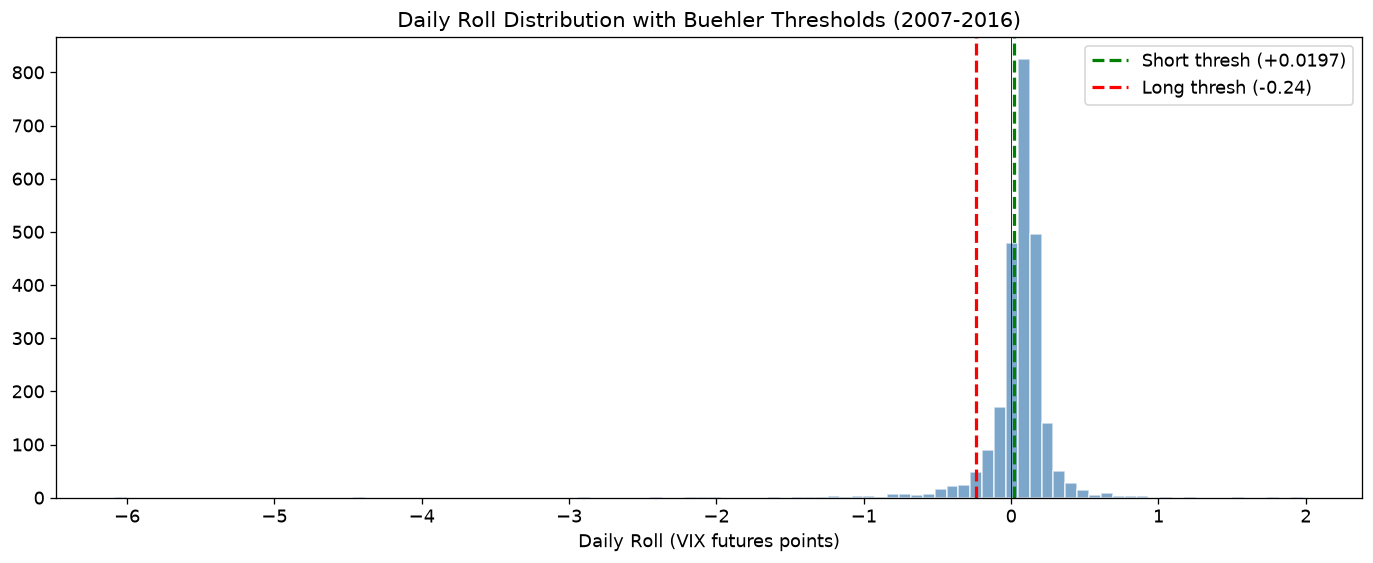


Days triggering SHORT (>=0.0197): 72.2%
Days triggering LONG  (<=-0.24): 5.6%
Days in CASH:                       22.2%


In [14]:
roll_buehler = data.loc['2007':'2016', 'daily_roll'].dropna()
print('=== Daily Roll Distribution (Jan 2007 - Dec 2016) ===')
print(roll_buehler.describe().to_string())

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(roll_buehler, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(BUEHLER_SHORT, color='green', ls='--', lw=2, label=f'Short thresh (+{BUEHLER_SHORT})')
ax.axvline(BUEHLER_LONG, color='red', ls='--', lw=2, label=f'Long thresh ({BUEHLER_LONG})')
ax.axvline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Daily Roll (VIX futures points)')
ax.set_title('Daily Roll Distribution with Buehler Thresholds (2007-2016)')
ax.legend()
plt.tight_layout()
plt.show()

pct_short = (roll_buehler >= BUEHLER_SHORT).mean()
pct_long  = (roll_buehler <= BUEHLER_LONG).mean()
pct_cash  = 1 - pct_short - pct_long
print(f'\nDays triggering SHORT (>={BUEHLER_SHORT}): {pct_short:.1%}')
print(f'Days triggering LONG  (<={BUEHLER_LONG}): {pct_long:.1%}')
print(f'Days in CASH:                       {pct_cash:.1%}')

## 9. VIX Spot vs Nearest Futures & Daily Roll

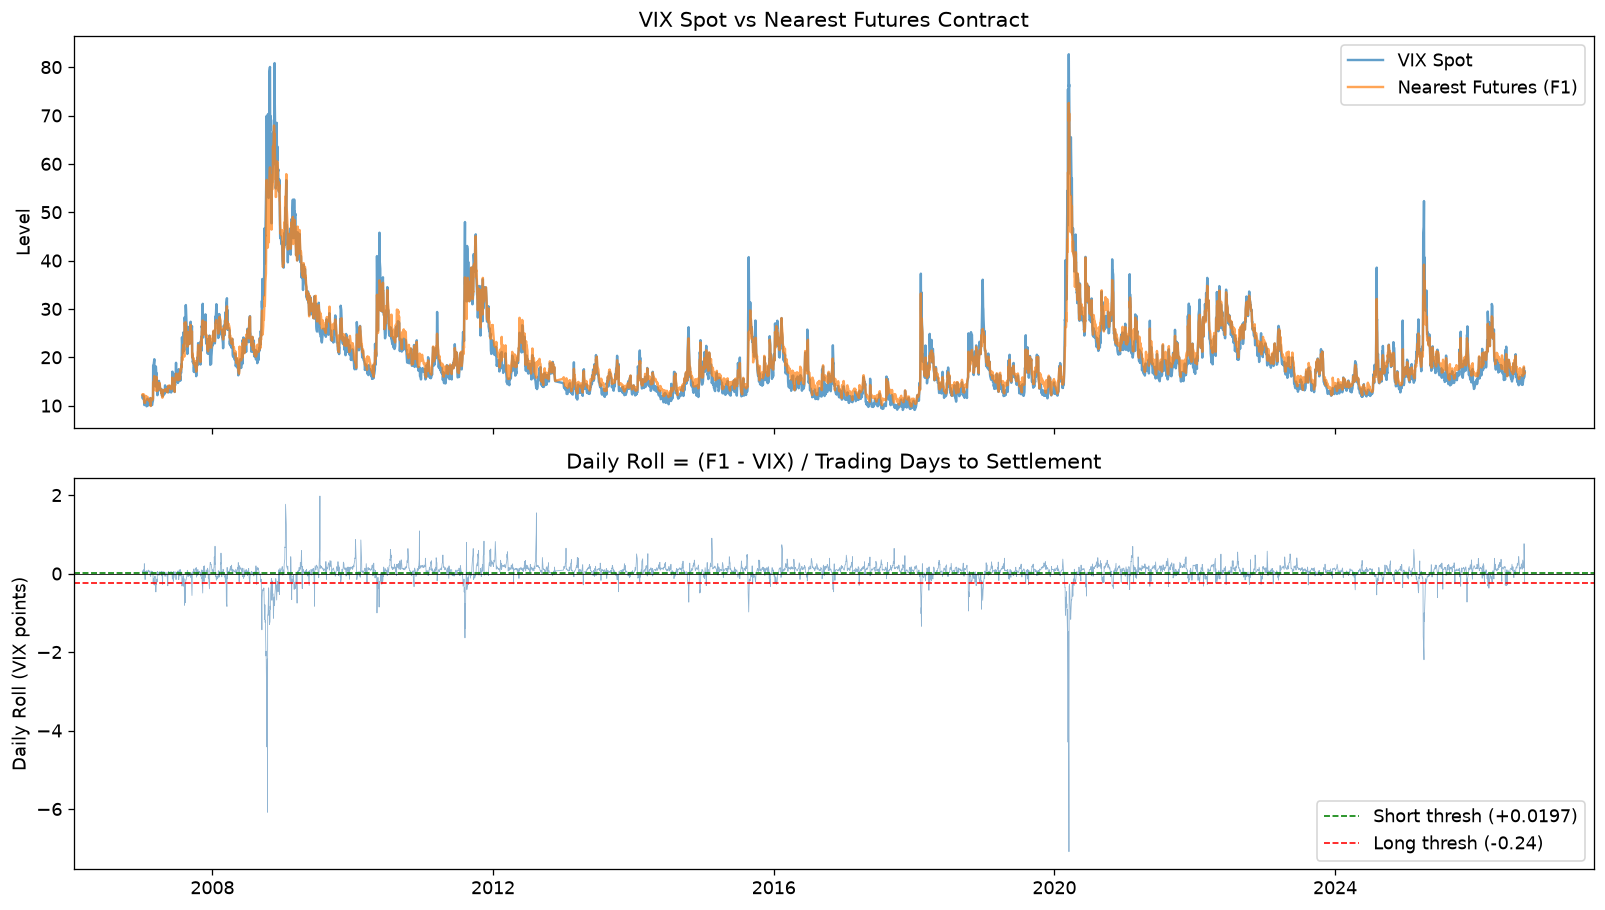

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data['VIX'], label='VIX Spot', alpha=0.7)
axes[0].plot(data.index, data['F1_settle'], label='Nearest Futures (F1)', alpha=0.7)
axes[0].set_ylabel('Level')
axes[0].legend()
axes[0].set_title('VIX Spot vs Nearest Futures Contract')

axes[1].plot(data.index, data['daily_roll'], color='steelblue', alpha=0.6, lw=0.5)
axes[1].axhline(BUEHLER_SHORT, color='green', ls='--', lw=1,
                label=f'Short thresh (+{BUEHLER_SHORT})')
axes[1].axhline(BUEHLER_LONG, color='red', ls='--', lw=1,
                label=f'Long thresh ({BUEHLER_LONG})')
axes[1].axhline(0, color='black', ls='-', lw=0.5)
axes[1].set_ylabel('Daily Roll (VIX points)')
axes[1].set_title('Daily Roll = (F1 - VIX) / Trading Days to Settlement')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Strategy Engine

**v4 changes:**
- Removed futures strategy entirely
- Added quarterly-rebalanced portfolio backtest
- `backtest()` is for the pure vol strategy (ETF only)
- `backtest_portfolio()` handles SPX/Vol blending with quarterly rebalancing


In [16]:
def generate_signals(data, short_thresh, long_thresh):
    prev_roll = data['daily_roll'].shift(1)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal


def backtest(data, signal, start=None, end=None, use_adj_svxy=True):
    """Pure vol strategy backtest (no portfolio blending)."""
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY_ret', 'VIXY_ret'])
    if len(df) == 0:
        return pd.DataFrame(), {}

    svxy_col = 'SVXY_ret_adj' if use_adj_svxy else 'SVXY_ret'

    df['etf_ret'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'etf_ret'] = df.loc[df['signal'] == 'SVXY', svxy_col]
    df.loc[df['signal'] == 'VIXY', 'etf_ret'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']

    # Also track raw (unadjusted) for comparison
    df['etf_ret_raw'] = 0.0
    df.loc[df['signal'] == 'SVXY', 'etf_ret_raw'] = df.loc[df['signal'] == 'SVXY', 'SVXY_ret']
    df.loc[df['signal'] == 'VIXY', 'etf_ret_raw'] = df.loc[df['signal'] == 'VIXY', 'VIXY_ret']

    df['etf_equity'] = (1 + df['etf_ret']).cumprod()
    df['etf_equity_raw'] = (1 + df['etf_ret_raw']).cumprod()
    df['spy_equity'] = (1 + df['SPY_ret']).cumprod()

    n = len(df); yrs = n / 252
    terminal = df['etf_equity'].iloc[-1]
    cagr = terminal ** (1/yrs) - 1 if yrs > 0 else 0
    vol = df['etf_ret'].std() * np.sqrt(252)
    sharpe = (df['etf_ret'].mean() * 252) / vol if vol > 0 else 0
    semi = df['etf_ret'][df['etf_ret'] < 0].std() * np.sqrt(252)
    sortino = (df['etf_ret'].mean() * 252) / semi if semi > 0 else 0
    dd = (df['etf_equity'] / df['etf_equity'].cummax()) - 1
    n_trades = (df['signal'] != df['signal'].shift(1)).sum()

    stats = {
        'Terminal ($1)': f'{terminal:.2f}',
        'CAGR': f'{cagr:.1%}', 'Vol (ann.)': f'{vol:.1%}',
        'Sharpe': f'{sharpe:.2f}', 'Sortino': f'{sortino:.2f}',
        'Max DD': f'{dd.min():.1%}',
        'Trades': n_trades,
        'Days Short': (df['signal']=='SVXY').sum(),
        'Days Long': (df['signal']=='VIXY').sum(),
        'Days Cash': (df['signal']=='CASH').sum(),
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats


def backtest_portfolio(data, signal, w_vol, start=None, end=None,
                       use_adj_svxy=True, rebal_every=63):
    """
    Portfolio backtest: SPX + Vol strategy with periodic rebalancing.
    Between rebalance dates, allocations drift with returns.
    
    Parameters
    ----------
    w_vol : float
        Target weight for the vol strategy (e.g. 0.30)
    rebal_every : int
        Rebalance every N trading days (~63 = quarterly)
    """
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY_ret', 'VIXY_ret', 'SPY_ret']).copy()
    if len(df) == 0:
        return pd.DataFrame(), {}

    svxy_col = 'SVXY_ret_adj' if use_adj_svxy else 'SVXY_ret'
    w_spy = 1.0 - w_vol

    # Vol strategy return per day
    vol_ret = np.zeros(len(df))
    mask_svxy = df['signal'].values == 'SVXY'
    mask_vixy = df['signal'].values == 'VIXY'
    vol_ret[mask_svxy] = df[svxy_col].values[mask_svxy]
    vol_ret[mask_vixy] = df['VIXY_ret'].values[mask_vixy]
    spy_ret = df['SPY_ret'].values.copy()

    # Track allocations with periodic rebalancing
    vol_alloc = w_vol   # dollar allocation (starting from $1 total)
    spy_alloc = w_spy
    equity = np.ones(len(df))
    equity[0] = 1.0

    for i in range(1, len(df)):
        # Daily P&L
        vol_alloc *= (1 + vol_ret[i])
        spy_alloc *= (1 + spy_ret[i])
        total = vol_alloc + spy_alloc
        equity[i] = total

        # Periodic rebalancing
        if i % rebal_every == 0:
            vol_alloc = total * w_vol
            spy_alloc = total * w_spy

    df['port_equity'] = equity
    df['spy_only_eq'] = (1 + df['SPY_ret']).cumprod()

    n = len(df); yrs = n / 252
    terminal = equity[-1]
    cagr = terminal ** (1/yrs) - 1 if yrs > 0 else 0
    port_ret = np.diff(equity) / equity[:-1]
    ann_vol = np.std(port_ret) * np.sqrt(252)
    sharpe = (np.mean(port_ret) * 252) / ann_vol if ann_vol > 0 else 0
    neg = port_ret[port_ret < 0]
    semi = np.std(neg) * np.sqrt(252) if len(neg) > 0 else 1
    sortino = (np.mean(port_ret) * 252) / semi if semi > 0 else 0
    dd = (equity / np.maximum.accumulate(equity)) - 1

    stats = {
        'Terminal ($1)': f'{terminal:.2f}', 'CAGR': f'{cagr:.1%}',
        'Vol (ann.)': f'{ann_vol:.1%}', 'Sharpe': f'{sharpe:.2f}',
        'Sortino': f'{sortino:.2f}', 'Max DD': f'{dd.min():.1%}',
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats


print('Engine ready.')

Engine ready.


## 11. Buehler Replication (Oct 2011 – Dec 2016)

Using the published thresholds (+0.0197 / -0.240). ETF strategy only.
This period is entirely pre-leverage-change.


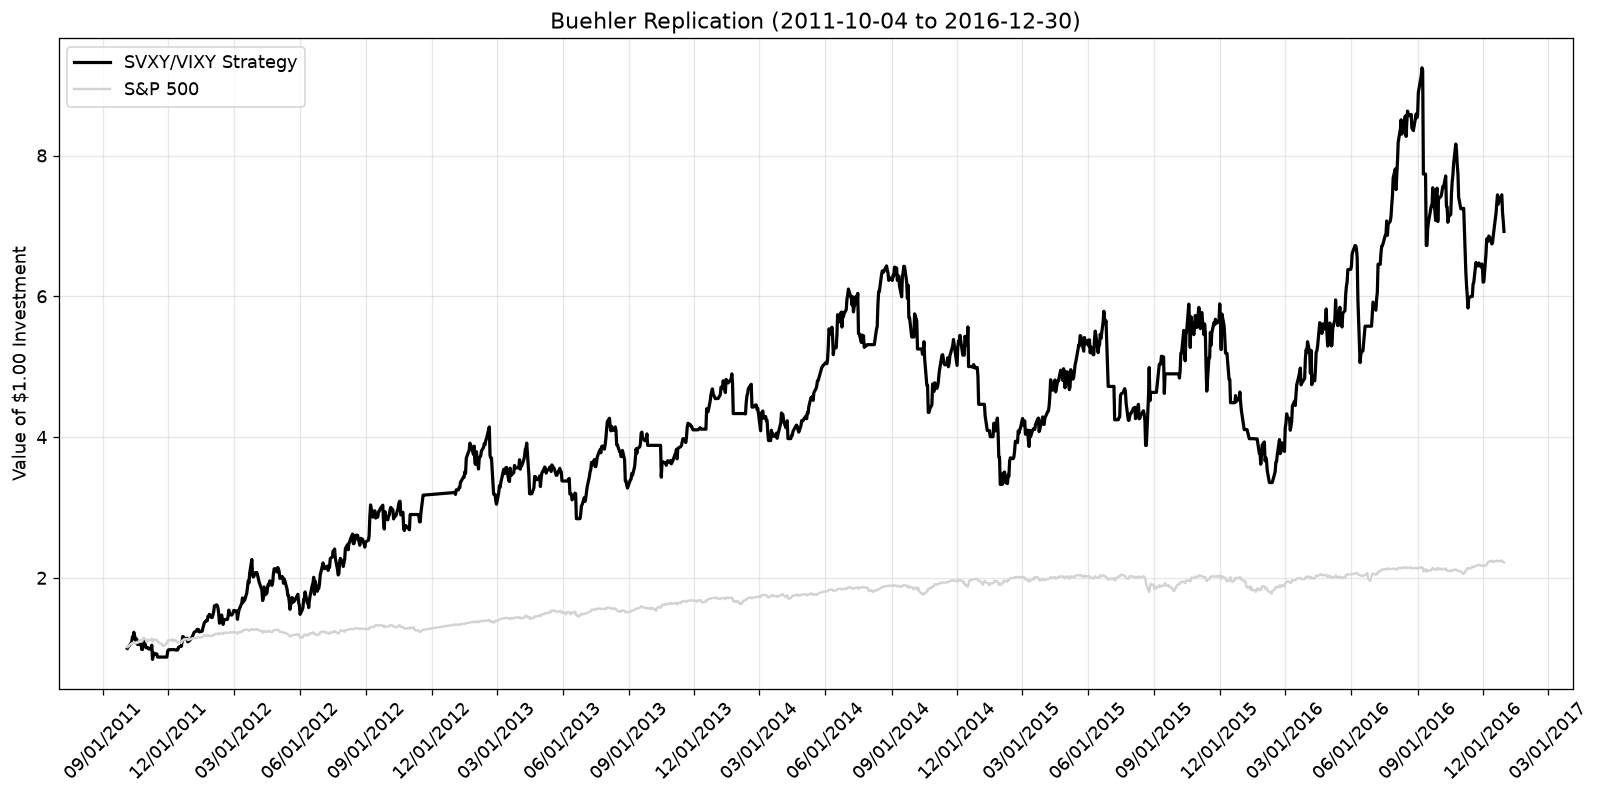


=== Buehler Replication Stats ===
  (Paper reports: Terminal=$15.23, CAGR=68.10%)
  Terminal ($1)       : 6.92
  CAGR                : 45.8%
  Vol (ann.)          : 53.8%
  Sharpe              : 0.98
  Sortino             : 1.10
  Max DD              : -48.2%
  Trades              : 163
  Days Short          : 1058
  Days Long           : 26
  Days Cash           : 208
  Period              : 2011-10-05 to 2016-12-30


In [17]:
sig_buehler = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_b, stats_b = backtest(data, sig_buehler, start=BUEHLER_OOS_START, end=BUEHLER_OOS_END)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_b.index, bt_b['etf_equity'], 'k-', lw=2, label='SVXY/VIXY Strategy')
ax.plot(bt_b.index, bt_b['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')
ax.set_title(f'Buehler Replication ({BUEHLER_OOS_START} to {BUEHLER_OOS_END})', fontsize=14)
ax.set_ylabel('Value of $1.00 Investment')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n=== Buehler Replication Stats ===')
print(f'  (Paper reports: Terminal=$15.23, CAGR=68.10%)')
for k, v in stats_b.items():
    print(f'  {k:20s}: {v}')

## 12. Threshold Optimisation (80/20 Train/Test Split)

Grid search optimising **Sharpe ratio** on the first 80% of ETF data.
Combos with < 20 trades are penalised.


ETF data: 2011-10-04 to 2026-09-14 (3730 days)
Train (80%): 2011-10-04 to 2023-09-21 (2984 days)
Test  (20%): 2023-09-22 to 2026-09-14 (746 days)
  Volmageddon: in train
  COVID: in train

=== Optimal Thresholds (Train Set, max Sharpe, >=20 trades) ===
  Short: 0.0300  (Buehler: 0.0197)
  Long:  -0.4000  (Buehler: -0.24)
  Sharpe: 1.130
  Terminal: $230.07
  Max DD: -63.2%
  Trades: 428


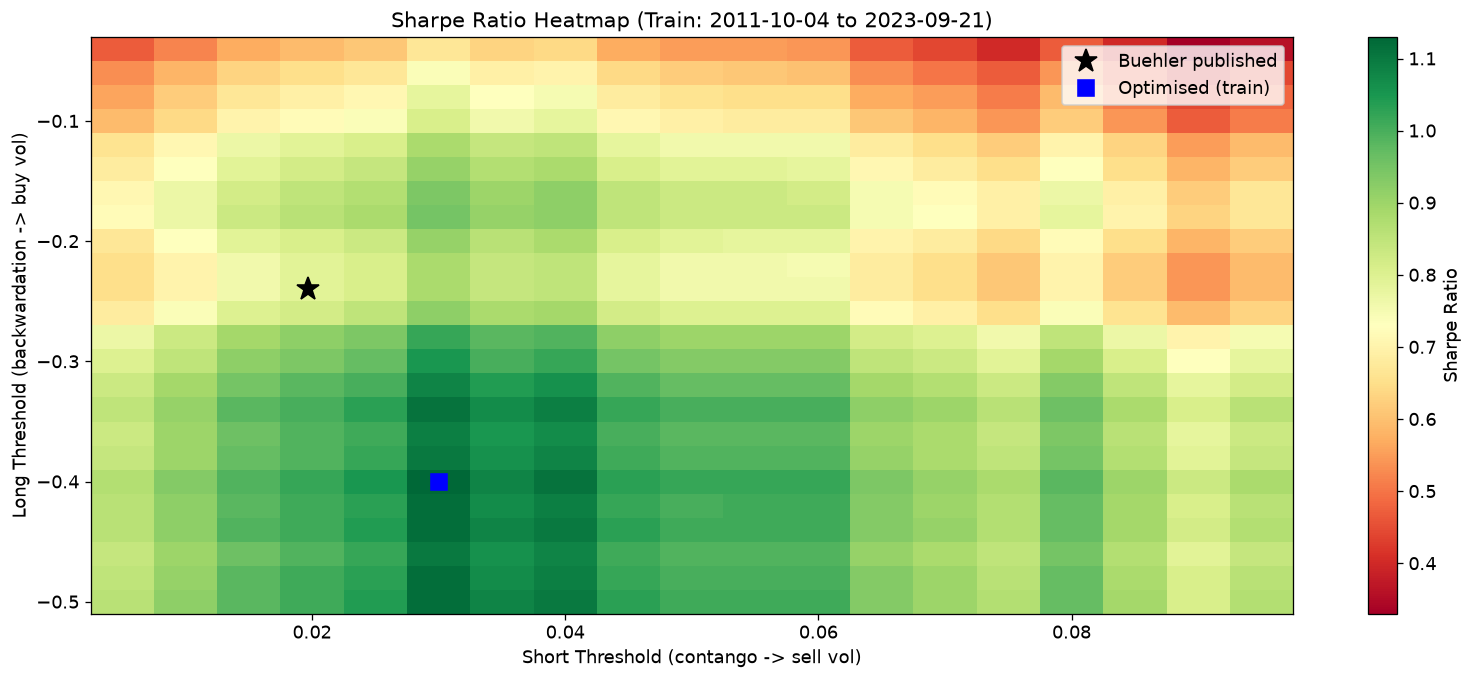

In [18]:
etf_data = data.dropna(subset=['SVXY', 'VIXY']).copy()
etf_start = etf_data.index.min().strftime('%Y-%m-%d')

split_idx = int(len(etf_data) * 0.80)
train_end = etf_data.index[split_idx - 1]
test_start = etf_data.index[split_idx]
train_end_str = train_end.strftime('%Y-%m-%d')
test_start_str = test_start.strftime('%Y-%m-%d')

print(f'ETF data: {etf_start} to {etf_data.index.max().date()} ({len(etf_data)} days)')
print(f'Train (80%): {etf_start} to {train_end.date()} ({split_idx} days)')
print(f'Test  (20%): {test_start.date()} to {etf_data.index.max().date()} ({len(etf_data) - split_idx} days)')

for evt, dt in [('Volmageddon', '2018-02-05'), ('COVID', '2020-03-16')]:
    print(f'  {evt}: {"OOS" if pd.Timestamp(dt) >= test_start else "in train"}')

MIN_TRADES = 20

short_grid = np.arange(0.005, 0.10, 0.005)
long_grid  = np.arange(-0.50, -0.02, 0.02)

results = []
for st in short_grid:
    for lt in long_grid:
        sig = generate_signals(data, st, lt)
        bt_tmp, stats_tmp = backtest(data, sig, start=etf_start, end=train_end_str)
        if len(bt_tmp) == 0:
            continue
        n_trades = int(stats_tmp['Trades'])
        sharpe = float(stats_tmp['Sharpe'])
        if n_trades < MIN_TRADES:
            sharpe = -999
        results.append({
            'short_thresh': round(st, 4),
            'long_thresh': round(lt, 4),
            'sharpe': sharpe,
            'terminal': bt_tmp['etf_equity'].iloc[-1],
            'max_dd': (bt_tmp['etf_equity'] / bt_tmp['etf_equity'].cummax() - 1).min(),
            'trades': n_trades,
        })

res_df = pd.DataFrame(results)
valid = res_df[res_df['sharpe'] > -900]
best = valid.loc[valid['sharpe'].idxmax()]
OPT_SHORT = best['short_thresh']
OPT_LONG  = best['long_thresh']

print(f'\n=== Optimal Thresholds (Train Set, max Sharpe, >={MIN_TRADES} trades) ===')
print(f'  Short: {OPT_SHORT:.4f}  (Buehler: {BUEHLER_SHORT})')
print(f'  Long:  {OPT_LONG:.4f}  (Buehler: {BUEHLER_LONG})')
print(f'  Sharpe: {best["sharpe"]:.3f}')
print(f'  Terminal: ${best["terminal"]:.2f}')
print(f'  Max DD: {best["max_dd"]:.1%}')
print(f'  Trades: {best["trades"]:.0f}')

pivot = valid.pivot_table(values='sharpe', index='long_thresh', columns='short_thresh')
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap='RdYlGn', shading='auto')
ax.plot(BUEHLER_SHORT, BUEHLER_LONG, 'k*', markersize=15, label='Buehler published')
ax.plot(OPT_SHORT, OPT_LONG, 'bs', markersize=10, label='Optimised (train)')
ax.set_xlabel('Short Threshold (contango -> sell vol)')
ax.set_ylabel('Long Threshold (backwardation -> buy vol)')
ax.set_title(f'Sharpe Ratio Heatmap (Train: {etf_start} to {train_end_str})')
ax.legend(fontsize=11)
plt.colorbar(im, label='Sharpe Ratio')
plt.tight_layout()
plt.show()

## 13. Out-of-Sample Test (OOS 20%)

Both Volmageddon (Feb 2018) and COVID (Mar 2020) are fully out-of-sample.


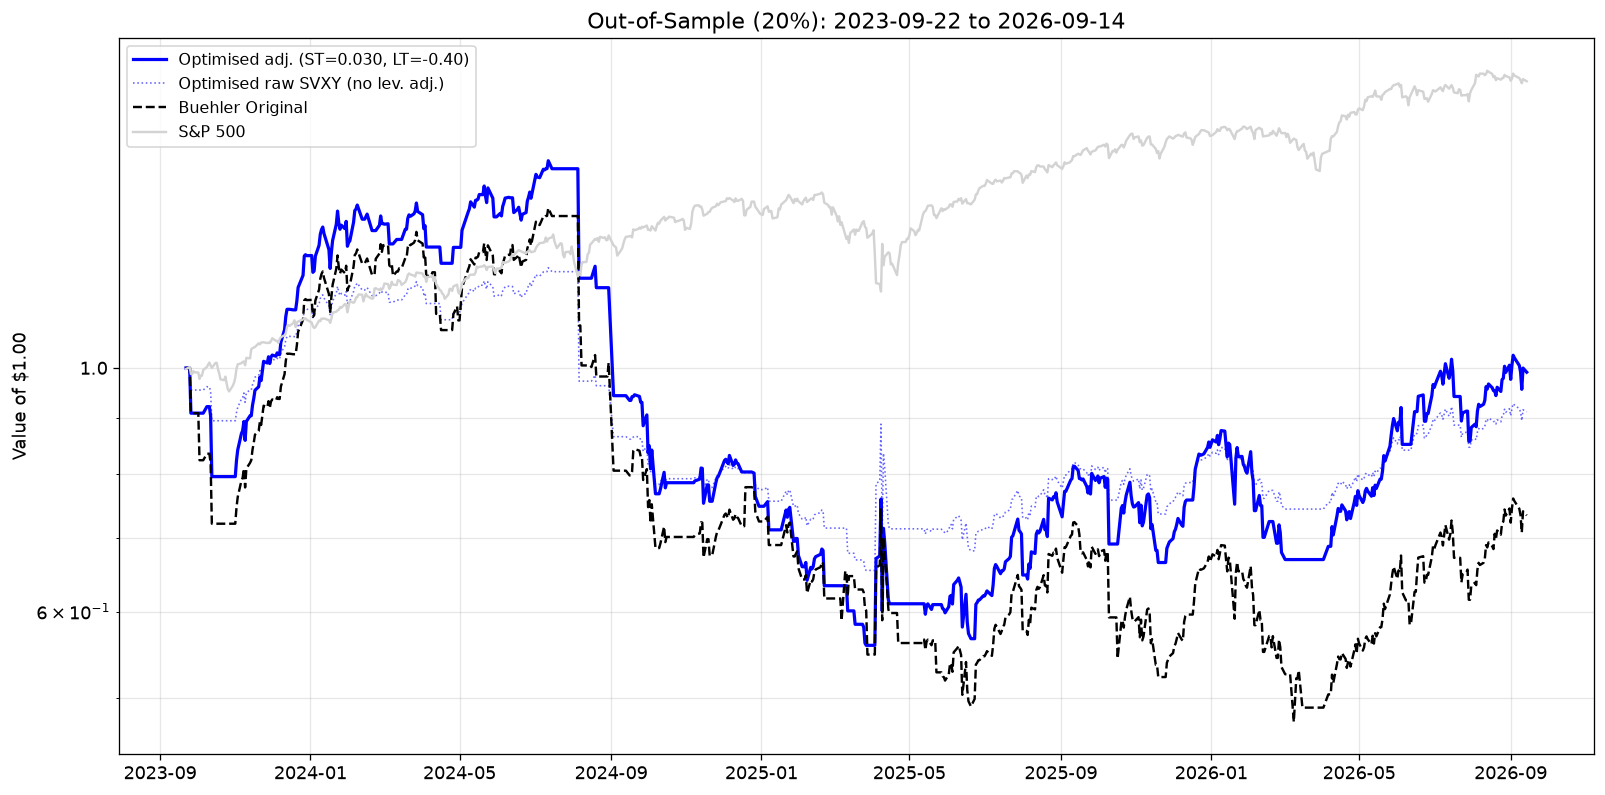


=== Out-of-Sample Results ===


,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised (adj),0.99,-0.3%,44.8%,0.22,0.19,-63.8%,134,472,14,261,2023-09-22 to 2026-09-14
Buehler Original,0.73,-9.9%,48.5%,0.03,0.03,-66.0%,142,499,30,218,2023-09-22 to 2026-09-14


In [19]:
test_end = etf_data.index.max().strftime('%Y-%m-%d')

sig_opt = generate_signals(data, OPT_SHORT, OPT_LONG)
bt_opt, stats_opt = backtest(data, sig_opt, start=test_start_str, end=test_end)

sig_buehler_test = generate_signals(data, BUEHLER_SHORT, BUEHLER_LONG)
bt_buehler_test, stats_buehler_test = backtest(data, sig_buehler_test,
                                                start=test_start_str, end=test_end)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(bt_opt.index, bt_opt['etf_equity'], 'b-', lw=2,
        label=f'Optimised adj. (ST={OPT_SHORT:.3f}, LT={OPT_LONG:.2f})')
ax.plot(bt_opt.index, bt_opt['etf_equity_raw'], 'b:', lw=1, alpha=0.6,
        label='Optimised raw SVXY (no lev. adj.)')
ax.plot(bt_buehler_test.index, bt_buehler_test['etf_equity'], 'k--', lw=1.5,
        label='Buehler Original')
ax.plot(bt_opt.index, bt_opt['spy_equity'], color='lightgray', lw=1.5, label='S&P 500')

for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_opt.index.min() and evt <= bt_opt.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')

ax.set_title(f'Out-of-Sample (20%): {test_start_str} to {test_end}', fontsize=14)
ax.set_ylabel('Value of $1.00')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp = pd.DataFrame({'Optimised (adj)': stats_opt, 'Buehler Original': stats_buehler_test}).T
print('\n=== Out-of-Sample Results ===')
display(comp)

## 14. Full Period Equity Curve (Train + Test)

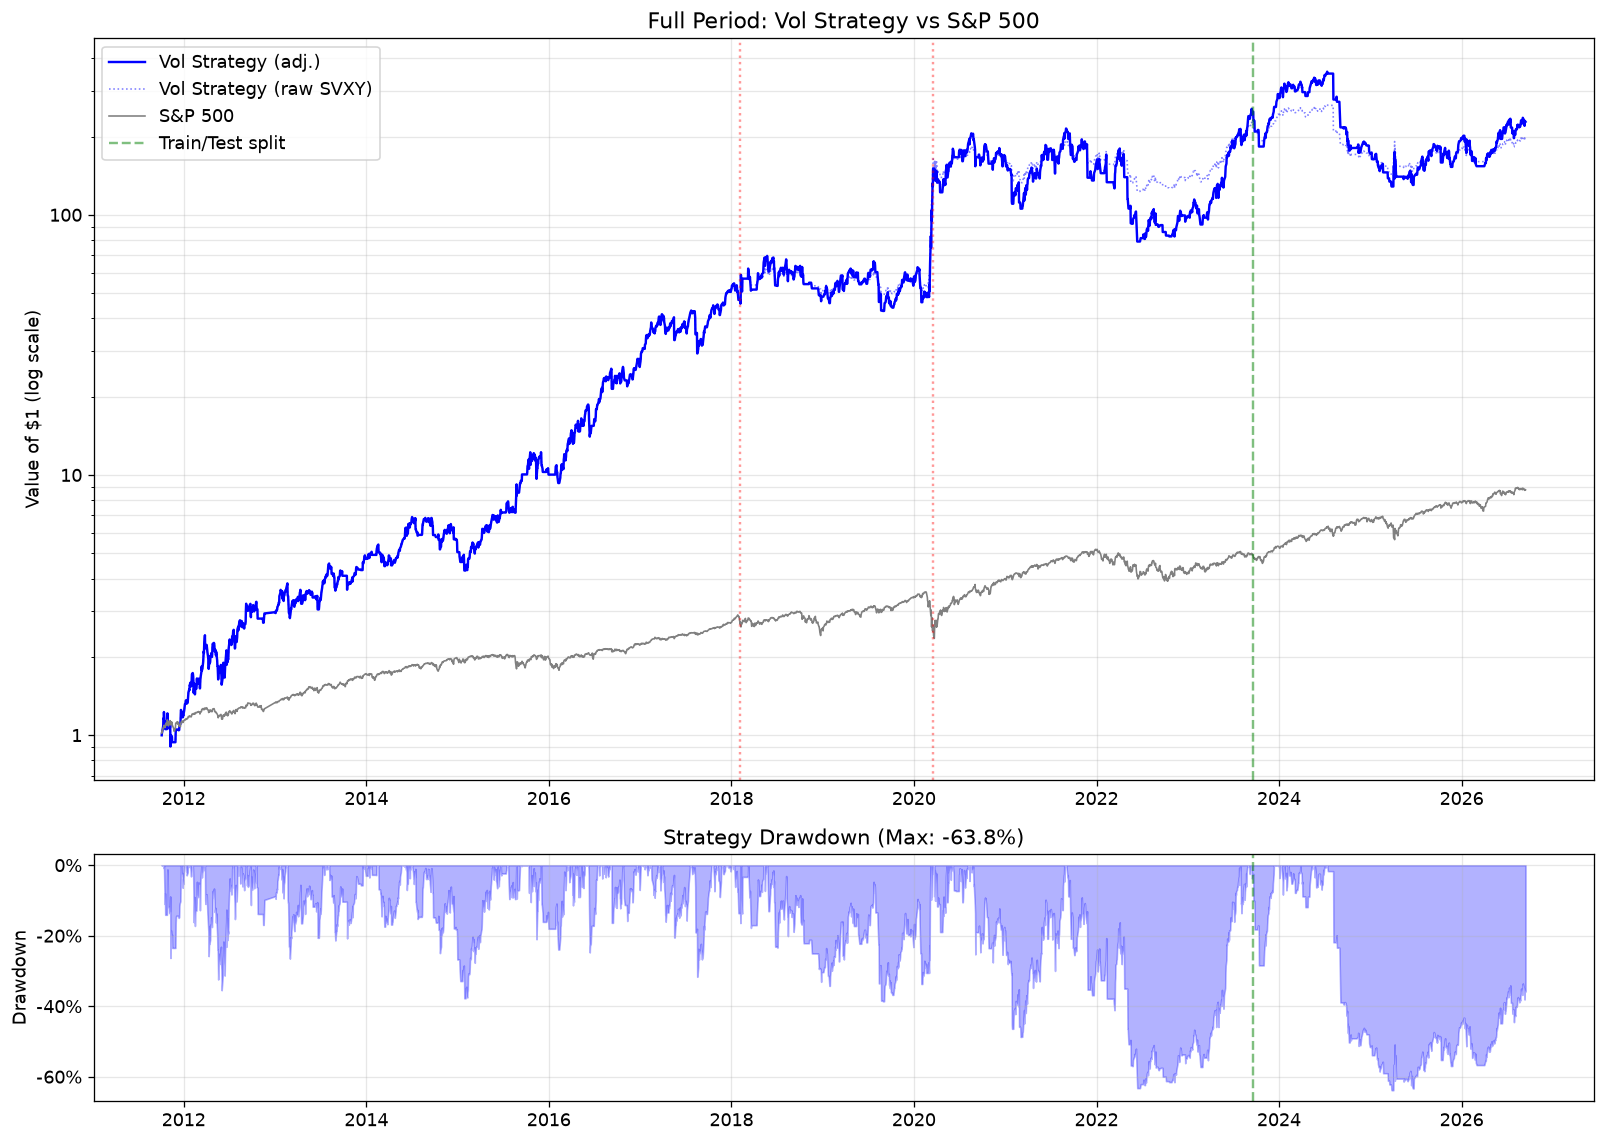


=== Full Period Stats ===
  Terminal ($1)       : 228.05
  CAGR                : 44.3%
  Vol (ann.)          : 52.0%
  Sharpe              : 0.97
  Sortino             : 1.00
  Max DD              : -63.8%
  Trades              : 562
  Days Short          : 2694
  Days Long           : 66
  Days Cash           : 970
  Period              : 2011-10-05 to 2026-09-14


In [20]:
full_start = etf_data.index.min().strftime('%Y-%m-%d')
full_end = etf_data.index.max().strftime('%Y-%m-%d')

bt_full, stats_full = backtest(data, sig_opt, start=full_start, end=full_end)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_full.index, bt_full['etf_equity'], 'b-', lw=1.5, label='Vol Strategy (adj.)')
ax.plot(bt_full.index, bt_full['etf_equity_raw'], 'b:', lw=1, alpha=0.5,
        label='Vol Strategy (raw SVXY)')
ax.plot(bt_full.index, bt_full['spy_equity'], color='gray', lw=1, label='S&P 500')
ax.axvline(train_end, color='green', ls='--', alpha=0.5, label='Train/Test split')
for dt in ['2018-02-05', '2020-03-16']:
    evt = pd.Timestamp(dt)
    if evt >= bt_full.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.4)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.set_title('Full Period: Vol Strategy vs S&P 500', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_full['etf_equity']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.axvline(train_end, color='green', ls='--', alpha=0.5)
ax2.set_ylabel('Drawdown')
ax2.set_title(f'Strategy Drawdown (Max: {dd.min():.1%})')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\n=== Full Period Stats ===')
for k, v in stats_full.items():
    print(f'  {k:20s}: {v}')

## 15. Portfolio: S&P 500 + Vol Strategy (Quarterly Rebalancing)

**v4:** Scans 0-50% vol weight using `backtest_portfolio()` with quarterly rebalancing.
No more constant-weight daily rebalancing — allocations drift between rebalance dates.


=== Optimal Portfolio Weights (Quarterly Rebal) ===

Max Sharpe: 17% Vol + 83% SPY
  Sharpe=1.22, CAGR=22.9%, Max DD=-29.3%


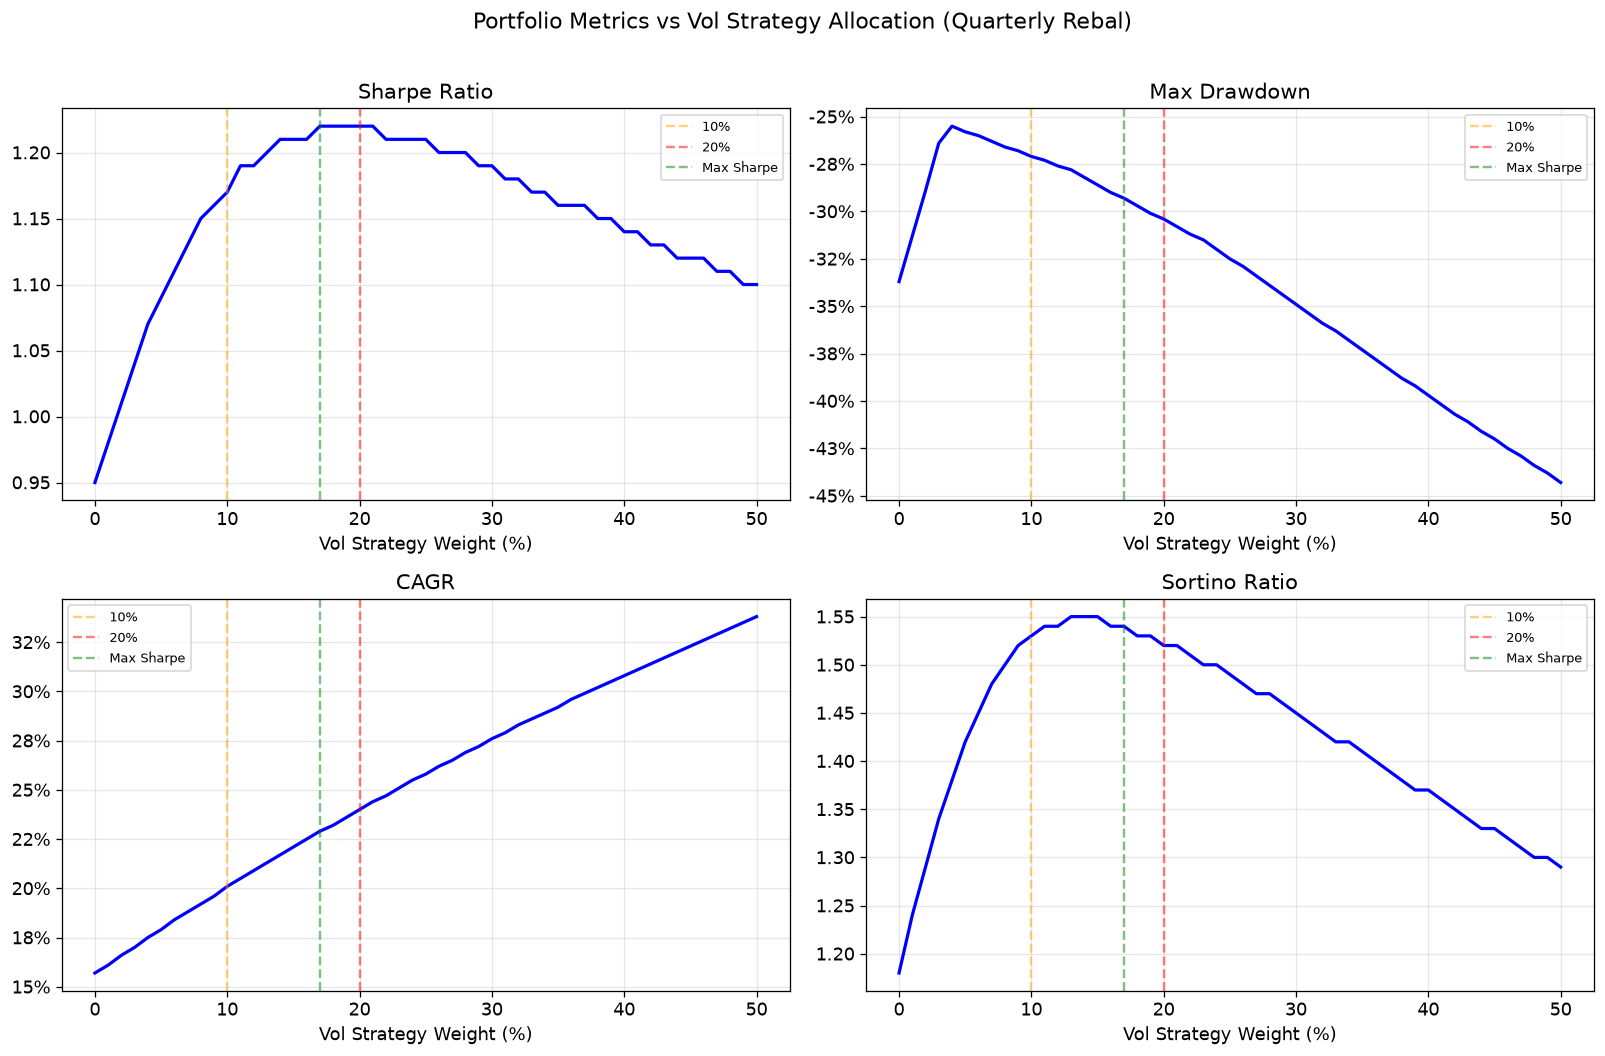

In [21]:
weights = np.arange(0.0, 0.51, 0.01)
port_results = []

for w_vol in weights:
    bt_p, stats_p = backtest_portfolio(
        data, sig_opt, w_vol=w_vol,
        start=full_start, end=full_end,
        rebal_every=REBAL_PERIOD_DAYS
    )
    if len(bt_p) == 0:
        continue
    port_results.append({
        'w_vol': w_vol, 'w_spy': 1 - w_vol,
        'cagr': float(stats_p['CAGR'].strip('%')) / 100,
        'vol': float(stats_p['Vol (ann.)'].strip('%')) / 100,
        'sharpe': float(stats_p['Sharpe']),
        'sortino': float(stats_p['Sortino']),
        'max_dd': float(stats_p['Max DD'].strip('%')) / 100,
        'terminal': float(stats_p['Terminal ($1)']),
    })

port_df = pd.DataFrame(port_results)
best_sharpe = port_df.loc[port_df['sharpe'].idxmax()]

print('=== Optimal Portfolio Weights (Quarterly Rebal) ===')
print(f'\nMax Sharpe: {best_sharpe["w_vol"]:.0%} Vol + {best_sharpe["w_spy"]:.0%} SPY')
print(f'  Sharpe={best_sharpe["sharpe"]:.2f}, CAGR={best_sharpe["cagr"]:.1%}, '
      f'Max DD={best_sharpe["max_dd"]:.1%}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric, title in [
    (axes[0,0], 'sharpe', 'Sharpe Ratio'),
    (axes[0,1], 'max_dd', 'Max Drawdown'),
    (axes[1,0], 'cagr', 'CAGR'),
    (axes[1,1], 'sortino', 'Sortino Ratio'),
]:
    ax.plot(port_df['w_vol'] * 100, port_df[metric], 'b-', lw=2)
    ax.set_xlabel('Vol Strategy Weight (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axvline(10, color='orange', ls='--', alpha=0.5, label='10%')
    ax.axvline(20, color='red', ls='--', alpha=0.5, label='20%')
    ax.axvline(best_sharpe['w_vol'] * 100, color='green', ls='--', alpha=0.5, label='Max Sharpe')
    if metric in ['max_dd', 'cagr']:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=8)

plt.suptitle('Portfolio Metrics vs Vol Strategy Allocation (Quarterly Rebal)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 16. Portfolio Equity Curves

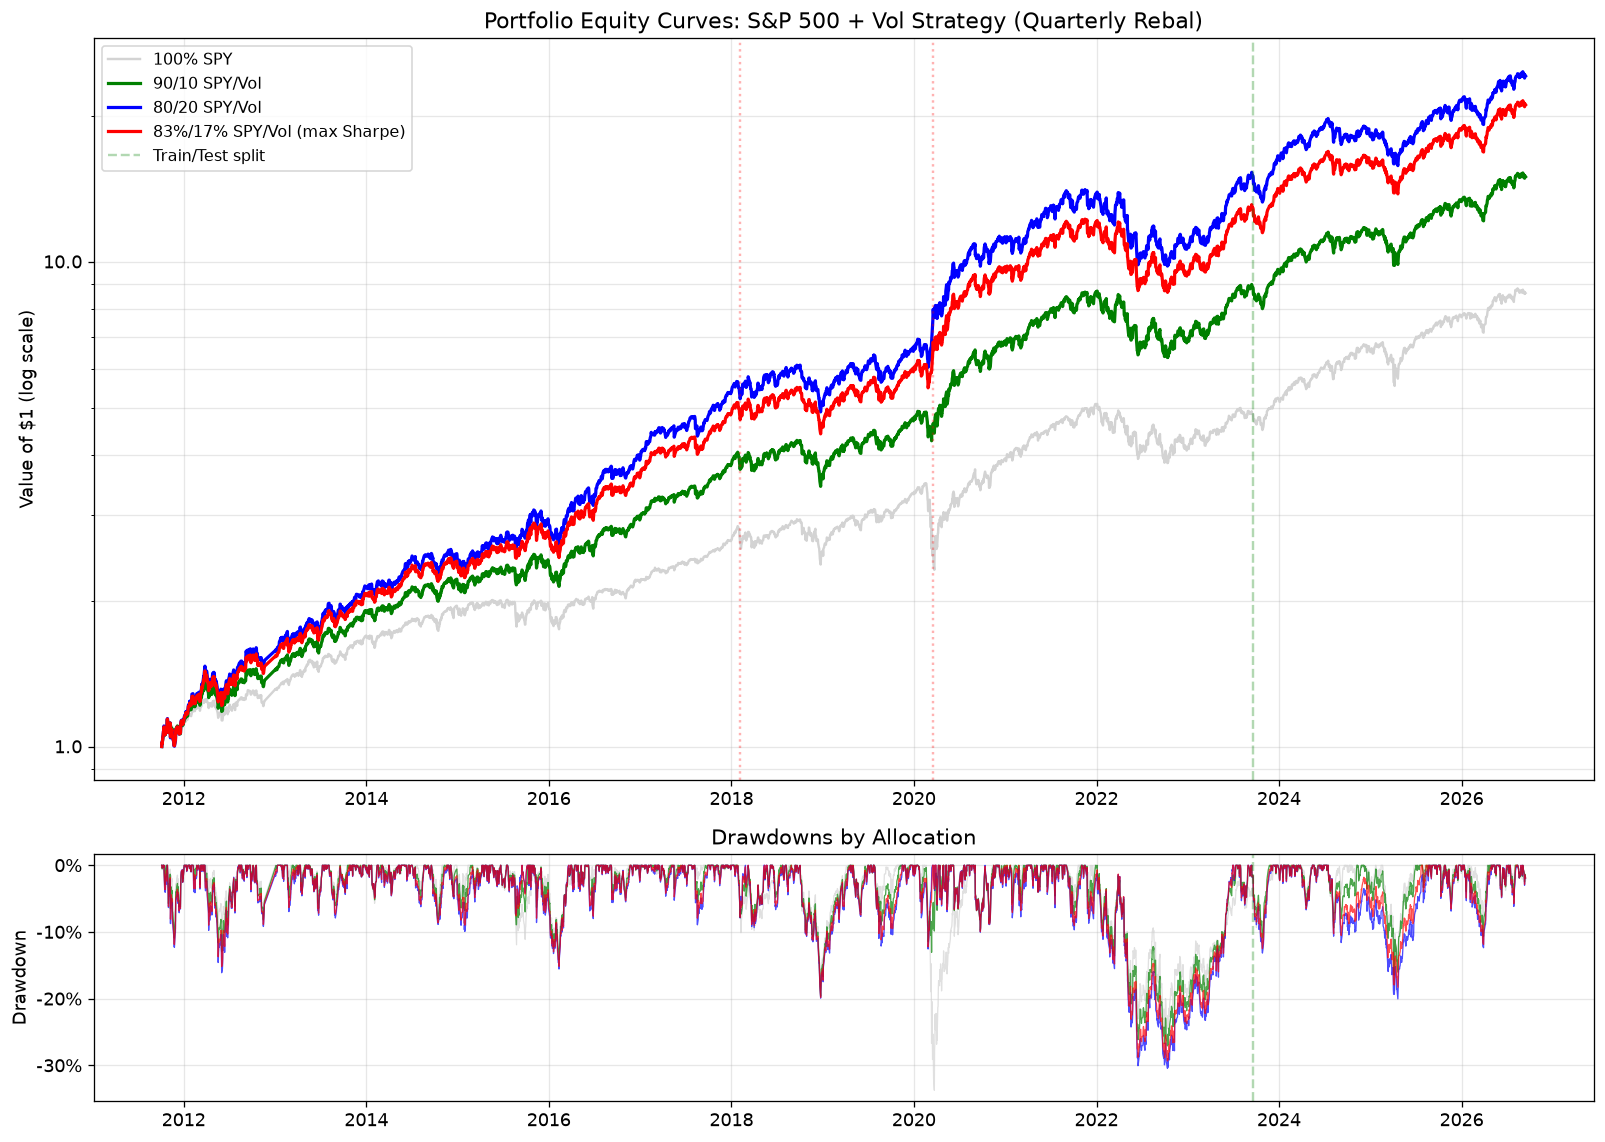

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

opt_w = best_sharpe['w_vol']
allocations = [
    (0.00, '100% SPY', 'lightgray'),
    (0.10, '90/10 SPY/Vol', 'green'),
    (0.20, '80/20 SPY/Vol', 'blue'),
    (opt_w, f'{1-opt_w:.0%}/{opt_w:.0%} SPY/Vol (max Sharpe)', 'red'),
]

ax = axes[0]
ax2 = axes[1]

for w_vol, label, color in allocations:
    bt_p, _ = backtest_portfolio(
        data, sig_opt, w_vol=w_vol,
        start=full_start, end=full_end,
        rebal_every=REBAL_PERIOD_DAYS
    )
    ax.plot(bt_p.index, bt_p['port_equity'], color=color,
            lw=2 if w_vol > 0 else 1.5, label=label)
    dd = (bt_p['port_equity'].values /
          np.maximum.accumulate(bt_p['port_equity'].values)) - 1
    ax2.plot(bt_p.index, dd, color=color, lw=0.8, alpha=0.7)

ax.axvline(train_end, color='green', ls='--', alpha=0.3, label='Train/Test split')
for dt in ['2018-02-05', '2020-03-16']:
    evt = pd.Timestamp(dt)
    if evt >= bt_p.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Portfolio Equity Curves: S&P 500 + Vol Strategy (Quarterly Rebal)', fontsize=14)
ax.set_ylabel('Value of $1 (log scale)')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

ax2.axvline(train_end, color='green', ls='--', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdowns by Allocation')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Summary Table — Key Allocations

In [23]:
summary_rows = []
for w_vol, label in [(0.0, '100% SPY'), (0.05, '95/5'), (0.10, '90/10'),
                      (0.15, '85/15'), (0.20, '80/20'),
                      (best_sharpe['w_vol'],
                       f'Max Sharpe ({1-best_sharpe["w_vol"]:.0%}/{best_sharpe["w_vol"]:.0%})')]:
    row = port_df.iloc[(port_df['w_vol'] - w_vol).abs().idxmin()]
    summary_rows.append({
        'Allocation': label,
        'Vol Wt': f'{row["w_vol"]:.0%}',
        'SPY Wt': f'{row["w_spy"]:.0%}',
        'CAGR': f'{row["cagr"]:.1%}',
        'Vol': f'{row["vol"]:.1%}',
        'Sharpe': f'{row["sharpe"]:.2f}',
        'Sortino': f'{row["sortino"]:.2f}',
        'Max DD': f'{row["max_dd"]:.1%}',
        'Terminal': f'${row["terminal"]:.2f}',
    })

display(pd.DataFrame(summary_rows).set_index('Allocation'))

,Vol Wt,SPY Wt,CAGR,Vol,Sharpe,Sortino,Max DD,Terminal
Allocation,,,,,,,,
100% SPY,0%,100%,15.7%,16.8%,0.95,1.18,-33.7%,$8.61
95/5,5%,95%,17.9%,16.4%,1.09,1.42,-25.8%,$11.47
90/10,10%,90%,20.1%,16.8%,1.17,1.53,-27.1%,$14.96
85/15,15%,85%,22.1%,17.8%,1.21,1.55,-28.6%,$19.16
80/20,20%,80%,24.0%,19.2%,1.22,1.52,-30.4%,$24.15
Max Sharpe (83%/17%),17%,83%,22.9%,18.3%,1.22,1.54,-29.3%,$21.06


---
# Part III: Robustness & Live-Readiness

## 18. Backtest with Realistic Trading Costs (Interactive Brokers)

**v4:** Both cost and no-cost versions use identical quarterly rebalancing.
The only difference is whether IB commissions + spread are charged on signal changes.


In [24]:
PORTFOLIO_EUR  = 20_000
EUR_USD        = 1.075
PORTFOLIO_USD  = PORTFOLIO_EUR * EUR_USD

COMMISSION_PER_SHARE = 0.0035
MIN_COMMISSION       = 0.35
MAX_COMMISSION_PCT   = 0.01

HALF_SPREAD_NORMAL = 0.0003
HALF_SPREAD_STRESS = 0.0008
VIX_STRESS_LEVEL   = 25

print(f'Portfolio: EUR {PORTFOLIO_EUR:,.0f} = ${PORTFOLIO_USD:,.0f}')

Portfolio: EUR 20,000 = $21,500


In [25]:
def backtest_with_costs(data, signal, portfolio_usd, w_vol=0.30,
                        start=None, end=None, use_adj_svxy=True,
                        rebal_every=63):
    """
    Portfolio backtest with IB trading costs and quarterly rebalancing.
    Both cost and no-cost equity use the same rebalancing schedule.
    """
    df = data.loc[start:end].copy() if start else data.copy()
    sig = signal.reindex(df.index).fillna('CASH')
    df['signal'] = sig
    df = df.dropna(subset=['SVXY', 'VIXY', 'SPY']).copy()
    if len(df) == 0:
        return pd.DataFrame(), {}

    svxy_col = 'SVXY_ret_adj' if use_adj_svxy else 'SVXY_ret'
    w_spy = 1.0 - w_vol

    # Vol strategy return per day
    vol_ret_arr = np.zeros(len(df))
    mask_svxy = df['signal'].values == 'SVXY'
    mask_vixy = df['signal'].values == 'VIXY'
    vol_ret_arr[mask_svxy] = df[svxy_col].values[mask_svxy]
    vol_ret_arr[mask_vixy] = df['VIXY_ret'].values[mask_vixy]
    spy_ret_arr = df['SPY_ret'].values.copy()

    # --- WITH COSTS ---
    vol_alloc = portfolio_usd * w_vol
    spy_alloc = portfolio_usd * w_spy
    equity_cost = np.zeros(len(df))
    equity_cost[0] = portfolio_usd
    total_costs = 0.0
    n_trades = 0
    prev_signal = 'CASH'

    for i in range(1, len(df)):
        cur_signal = df['signal'].iloc[i]
        row = df.iloc[i]
        prev_row = df.iloc[i-1]

        vol_pnl = vol_alloc * vol_ret_arr[i]
        spy_pnl = spy_alloc * spy_ret_arr[i]

        trade_cost = 0.0
        if cur_signal != prev_signal:
            n_trades += 1
            vix_now = row['VIX'] if not np.isnan(row['VIX']) else 15
            half_spread = HALF_SPREAD_STRESS if vix_now > VIX_STRESS_LEVEL else HALF_SPREAD_NORMAL

            if prev_signal != 'CASH':
                exit_px = prev_row['SVXY'] if prev_signal == 'SVXY' else prev_row['VIXY']
                if exit_px > 0 and not np.isnan(exit_px):
                    n_sh = vol_alloc / exit_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread

            if cur_signal != 'CASH':
                entry_px = row['SVXY'] if cur_signal == 'SVXY' else row['VIXY']
                if entry_px > 0 and not np.isnan(entry_px):
                    n_sh = vol_alloc / entry_px
                    comm = max(MIN_COMMISSION, min(n_sh * COMMISSION_PER_SHARE,
                                                   vol_alloc * MAX_COMMISSION_PCT))
                    trade_cost += comm + vol_alloc * half_spread

        total_costs += trade_cost
        vol_alloc = max(vol_alloc + vol_pnl - trade_cost, 0)
        spy_alloc += spy_pnl
        total = vol_alloc + spy_alloc
        equity_cost[i] = total
        prev_signal = cur_signal

        # Quarterly rebalance
        if i % rebal_every == 0:
            vol_alloc = total * w_vol
            spy_alloc = total * w_spy

    # --- WITHOUT COSTS (same rebalancing) ---
    vol_alloc_nc = w_vol
    spy_alloc_nc = w_spy
    equity_nocost = np.ones(len(df))

    for i in range(1, len(df)):
        vol_alloc_nc *= (1 + vol_ret_arr[i])
        spy_alloc_nc *= (1 + spy_ret_arr[i])
        total_nc = vol_alloc_nc + spy_alloc_nc
        equity_nocost[i] = total_nc
        if i % rebal_every == 0:
            vol_alloc_nc = total_nc * w_vol
            spy_alloc_nc = total_nc * w_spy

    # SPY only
    spy_only = np.cumprod(1 + spy_ret_arr)
    spy_only[0] = 1.0

    df['equity_cost'] = equity_cost
    df['equity_norm'] = equity_cost / equity_cost[0]
    df['nocost_equity'] = equity_nocost
    df['spy_only_eq'] = spy_only

    n = len(df); yrs = n / 252
    terminal_c = equity_cost[-1] / equity_cost[0]
    terminal_nc = equity_nocost[-1]
    cagr_c = terminal_c ** (1/yrs) - 1 if yrs > 0 else 0
    dd = (equity_cost / np.maximum.accumulate(equity_cost)) - 1

    stats = {
        'Terminal ($1)': f'{terminal_c:.2f}',
        'CAGR': f'{cagr_c:.1%}',
        'Max DD': f'{dd.min():.1%}',
        'Total costs ($)': f'{total_costs:.2f}',
        'Trades': n_trades,
        'Period': f"{df.index.min().date()} to {df.index.max().date()}",
    }
    return df, stats

print('Cost backtest ready.')

Cost backtest ready.


### 18a. Full Period: 70/30 SPY/Vol with Trading Costs

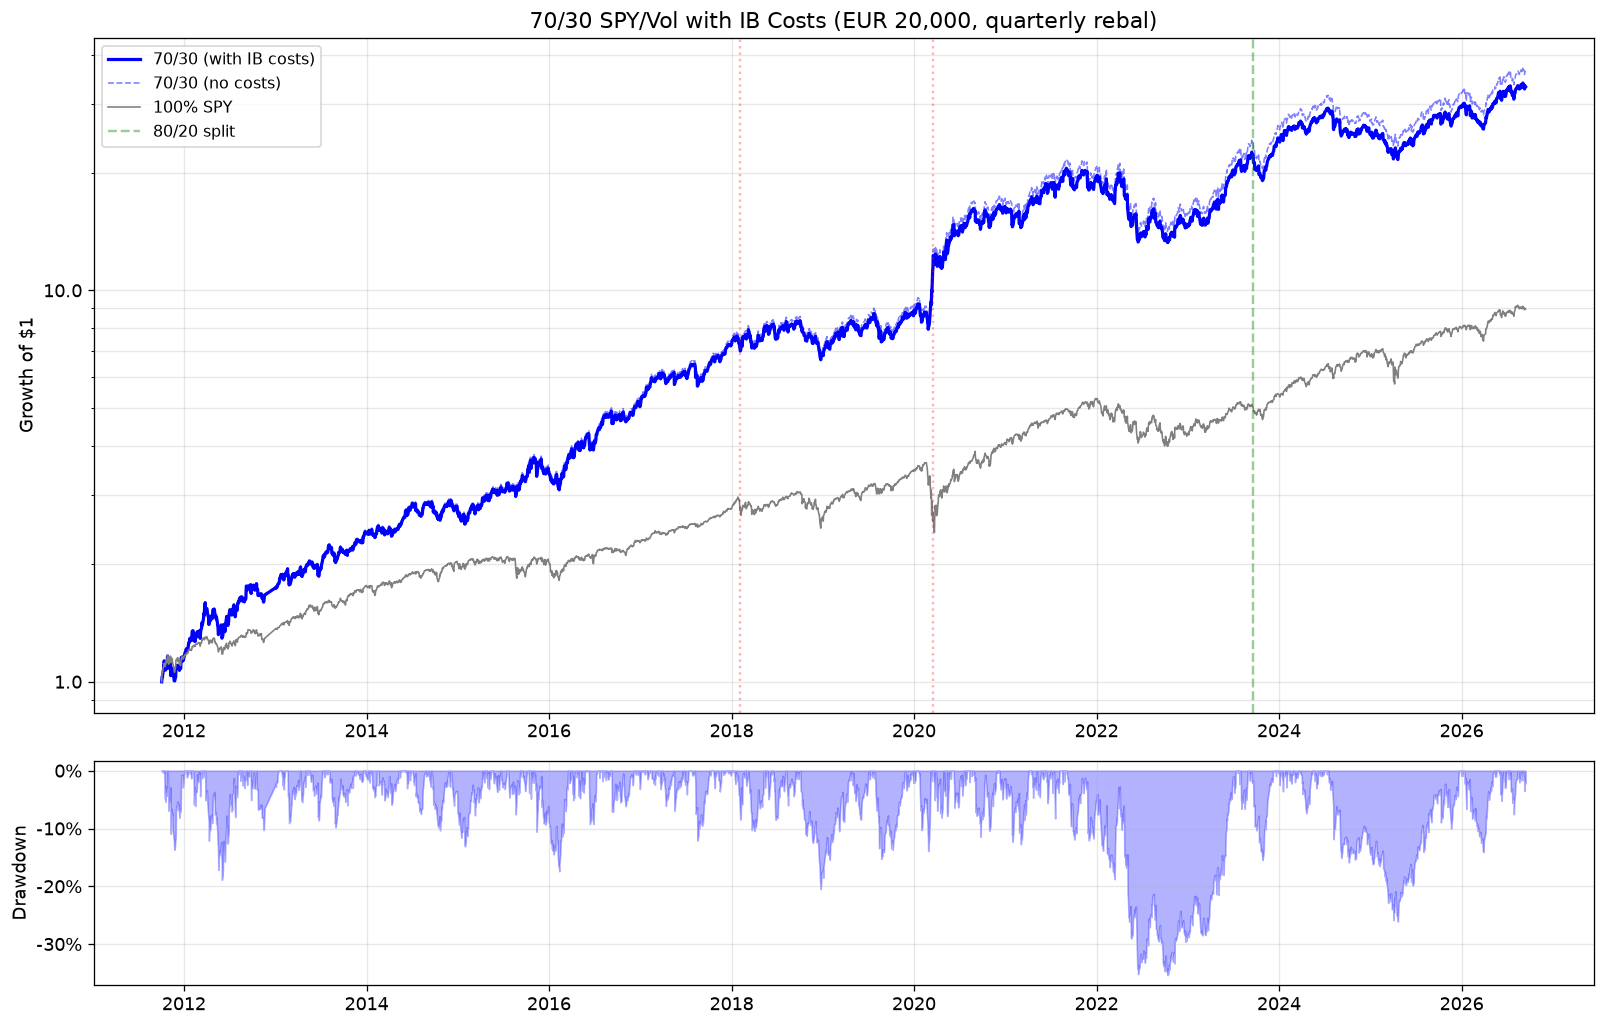


=== 70/30 Portfolio with IB Costs ===
  Terminal ($1)       : 33.17
  CAGR                : 26.7%
  Max DD              : -35.4%
  Total costs ($)     : 23084.74
  Trades              : 561
  Period              : 2011-10-04 to 2026-09-14
  Cost drag:          -8.24%


In [27]:
bt_cost, stats_cost = backtest_with_costs(
    data, sig_opt, PORTFOLIO_USD, w_vol=0.30,
    start=full_start, end=full_end,
    rebal_every=REBAL_PERIOD_DAYS
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 1])

ax = axes[0]
ax.plot(bt_cost.index, bt_cost['equity_norm'], 'b-', lw=2, label='70/30 (with IB costs)')
ax.plot(bt_cost.index, bt_cost['nocost_equity'], 'b--', lw=1, alpha=0.5, label='70/30 (no costs)')
ax.plot(bt_cost.index, bt_cost['spy_only_eq'], color='gray', lw=1, label='100% SPY')
ax.axvline(train_end, color='green', ls='--', alpha=0.4, label='80/20 split')
for dt in ['2018-02-05', '2020-03-16']:
    evt = pd.Timestamp(dt)
    if evt >= bt_cost.index.min():
        ax.axvline(evt, color='red', ls=':', alpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title(f'70/30 SPY/Vol with IB Costs (EUR {PORTFOLIO_EUR:,.0f}, quarterly rebal)', fontsize=14)
ax.set_ylabel('Growth of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

ax2 = axes[1]
eq = bt_cost['equity_norm']
dd = (eq / eq.cummax()) - 1
ax2.fill_between(dd.index, dd.values, 0, color='blue', alpha=0.3)
ax2.set_ylabel('Drawdown')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n=== 70/30 Portfolio with IB Costs ===')
for k, v in stats_cost.items():
    print(f'  {k:20s}: {v}')
cost_drag = bt_cost['equity_norm'].iloc[-1] / bt_cost['nocost_equity'].iloc[-1] - 1
print(f'  Cost drag:          {cost_drag:.2%}')

## 19. Robustness Check 1: Fixed 2016 Split (Volmageddon & COVID OOS)


Fixed split optimised: ST=0.0300, LT=-0.5000 (train Sharpe=1.55)


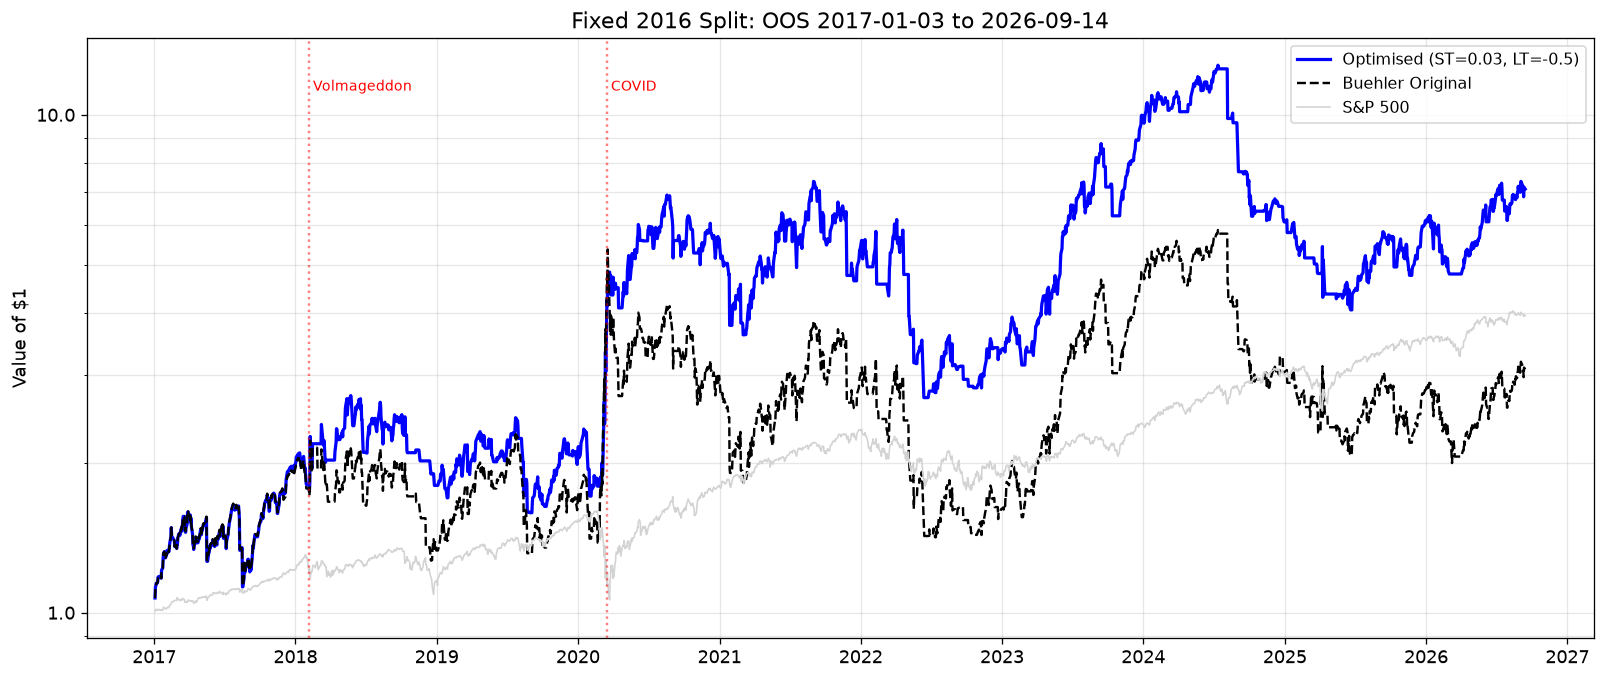

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Optimised,7.10,22.5%,52.1%,0.65,0.64,-67.7%,410,1673,45,720,2017-01-03 to 2026-09-14
Buehler,3.08,12.3%,56.0%,0.49,0.51,-73.6%,428,1745,107,586,2017-01-03 to 2026-09-14


In [28]:
FIXED_TRAIN_END  = '2016-12-30'
FIXED_TEST_START = '2017-01-03'

best_fixed_sharpe = -999
best_fixed_st, best_fixed_lt = BUEHLER_SHORT, BUEHLER_LONG
for st in np.arange(0.005, 0.10, 0.005):
    for lt in np.arange(-0.50, -0.02, 0.02):
        sig_tmp = generate_signals(data, st, lt)
        bt_tmp, s_tmp = backtest(data, sig_tmp, start=full_start, end=FIXED_TRAIN_END)
        if len(bt_tmp) == 0: continue
        n_tr = int(s_tmp['Trades'])
        s = float(s_tmp['Sharpe']) if n_tr >= MIN_TRADES else -999
        if s > best_fixed_sharpe:
            best_fixed_sharpe = s
            best_fixed_st, best_fixed_lt = round(st, 4), round(lt, 4)

print(f'Fixed split optimised: ST={best_fixed_st:.4f}, LT={best_fixed_lt:.4f} '
      f'(train Sharpe={best_fixed_sharpe:.2f})')

sig_fixed = generate_signals(data, best_fixed_st, best_fixed_lt)
bt_fixed, stats_fixed = backtest(data, sig_fixed, start=FIXED_TEST_START, end=full_end)
bt_fixed_b, stats_fixed_b = backtest(data, sig_buehler, start=FIXED_TEST_START, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_fixed.index, bt_fixed['etf_equity'], 'b-', lw=2,
        label=f'Optimised (ST={best_fixed_st}, LT={best_fixed_lt})')
ax.plot(bt_fixed_b.index, bt_fixed_b['etf_equity'], 'k--', lw=1.5, label='Buehler Original')
ax.plot(bt_fixed.index, bt_fixed['spy_equity'], color='lightgray', lw=1, label='S&P 500')
for dt, lbl in [('2018-02-05', 'Volmageddon'), ('2020-03-16', 'COVID')]:
    evt = pd.Timestamp(dt)
    if evt >= bt_fixed.index.min() and evt <= bt_fixed.index.max():
        ax.axvline(evt, color='red', ls=':', alpha=0.5)
        ax.text(evt, ax.get_ylim()[1]*0.85, f' {lbl}', fontsize=9, color='red')
ax.set_title(f'Fixed 2016 Split: OOS {FIXED_TEST_START} to {full_end}', fontsize=14)
ax.set_ylabel('Value of $1')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

comp_fixed = pd.DataFrame({'Optimised': stats_fixed, 'Buehler': stats_fixed_b}).T
display(comp_fixed)

## 20. Robustness Check 2: Walk-Forward Optimisation

Rolling 3-year train window, re-optimise yearly.

In [29]:
def walk_forward(data, etf_start, etf_end, train_years=3, step_months=12):
    results = []
    opt_dates = pd.date_range(
        start=pd.Timestamp(etf_start) + pd.DateOffset(years=train_years),
        end=etf_end, freq=f'{step_months}MS'
    )
    for opt_date in opt_dates:
        tr_s = (opt_date - pd.DateOffset(years=train_years)).strftime('%Y-%m-%d')
        tr_e = (opt_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        te_s = opt_date.strftime('%Y-%m-%d')
        te_e = (opt_date + pd.DateOffset(months=step_months) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')

        best_s, b_st, b_lt = -999, 0.02, -0.24
        for st in np.arange(0.005, 0.08, 0.01):
            for lt in np.arange(-0.50, -0.04, 0.04):
                sig_tmp = generate_signals(data, st, lt)
                bt_tmp, s_tmp = backtest(data, sig_tmp, start=tr_s, end=tr_e)
                if len(bt_tmp) == 0: continue
                n_tr = int(s_tmp['Trades'])
                s = float(s_tmp['Sharpe']) if n_tr >= 10 else -999
                if s > best_s:
                    best_s, b_st, b_lt = s, round(st, 4), round(lt, 4)

        results.append({
            'opt_date': opt_date, 'train': f'{tr_s} to {tr_e}',
            'test': f'{te_s} to {te_e}',
            'opt_short': b_st, 'opt_long': b_lt, 'train_sharpe': best_s,
        })
    return pd.DataFrame(results)

wf_results = walk_forward(data, full_start, full_end)
print('=== Walk-Forward Windows ===')
print(wf_results[['opt_date', 'opt_short', 'opt_long', 'train_sharpe']].to_string(index=False))

=== Walk-Forward Windows ===
  opt_date  opt_short  opt_long  train_sharpe
2014-11-01      0.025     -0.50          1.51
2015-11-01      0.065     -0.50          1.30
2016-11-01      0.035     -0.38          1.36
2017-11-01      0.045     -0.50          1.53
2018-11-01      0.055     -0.50          1.31
2019-11-01      0.075     -0.50          0.90
2020-11-01      0.075     -0.34          1.30
2021-11-01      0.075     -0.34          1.12
2022-11-01      0.015     -0.34          0.70
2023-11-01      0.025     -0.50          0.49
2024-11-01      0.035     -0.50          0.46
2025-11-01      0.035     -0.34          0.93


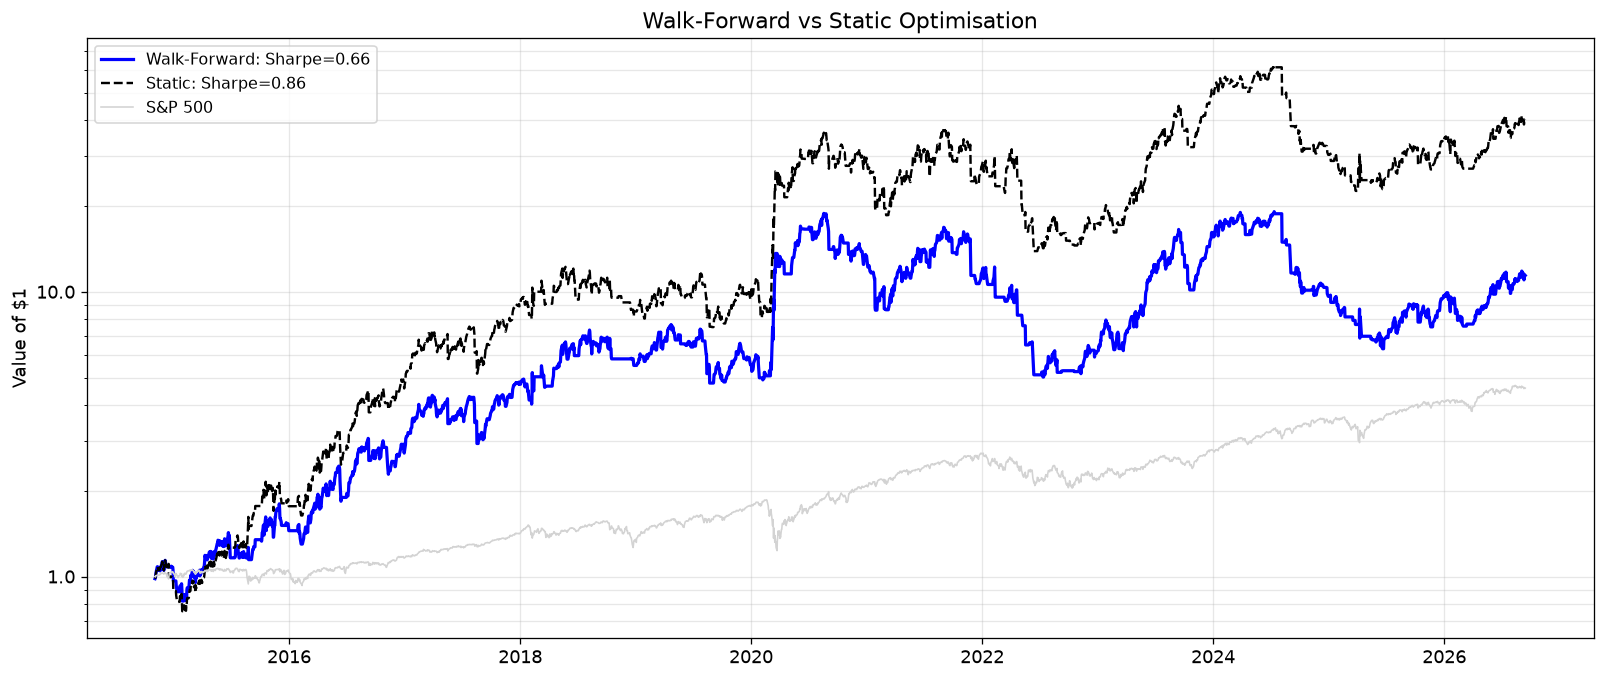

In [30]:
# Stitch OOS signals
wf_signal = pd.Series('CASH', index=data.index)
for _, row in wf_results.iterrows():
    ts, te = row['test'].split(' to ')
    sig_tmp = generate_signals(data, row['opt_short'], row['opt_long'])
    mask = (data.index >= ts) & (data.index <= te)
    wf_signal[mask] = sig_tmp[mask]

wf_start = wf_results.iloc[0]['test'].split(' to ')[0]
bt_wf, stats_wf = backtest(data, wf_signal, start=wf_start, end=full_end)
bt_static, stats_static = backtest(data, sig_opt, start=wf_start, end=full_end)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bt_wf.index, bt_wf['etf_equity'], 'b-', lw=2,
        label=f'Walk-Forward: Sharpe={stats_wf["Sharpe"]}')
ax.plot(bt_static.index, bt_static['etf_equity'], 'k--', lw=1.5,
        label=f'Static: Sharpe={stats_static["Sharpe"]}')
ax.plot(bt_wf.index, bt_wf['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Walk-Forward vs Static Optimisation', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 21. Robustness Check 3: Subperiod Analysis

Annual performance of the quarterly-rebalanced blend vs pure SPY.

In [31]:
# Use the quarterly-rebalanced portfolio for annual stats
bt_blend, _ = backtest_portfolio(data, sig_opt, w_vol=0.20,
                                  start=full_start, end=full_end,
                                  rebal_every=REBAL_PERIOD_DAYS)

# Compute daily returns from equity curve
bt_blend['port_ret'] = bt_blend['port_equity'].pct_change()

annual_stats = []
for yr in sorted(bt_blend.index.year.unique()):
    yr_data = bt_blend[bt_blend.index.year == yr].dropna(subset=['port_ret'])
    if len(yr_data) < 20: continue

    b_eq = (1 + yr_data['port_ret']).cumprod()
    s_eq = (1 + yr_data['SPY_ret']).cumprod()
    b_ret = b_eq.iloc[-1] - 1
    s_ret = s_eq.iloc[-1] - 1
    b_vol = yr_data['port_ret'].std() * np.sqrt(252)
    b_sharpe = (yr_data['port_ret'].mean() * 252) / b_vol if b_vol > 0 else 0
    b_dd = (b_eq / b_eq.cummax() - 1).min()
    s_dd = (s_eq / s_eq.cummax() - 1).min()
    in_train = pd.Timestamp(f'{yr}-06-30') <= train_end

    annual_stats.append({
        'Year': yr, 'Sample': 'TRAIN' if in_train else 'TEST',
        '70/30 Ret': f'{b_ret:.1%}', 'SPY Ret': f'{s_ret:.1%}',
        '70/30 Sharpe': f'{b_sharpe:.2f}',
        '70/30 MaxDD': f'{b_dd:.1%}', 'SPY MaxDD': f'{s_dd:.1%}',
        'Beats SPY': 'Y' if b_ret > s_ret else 'N',
    })

annual_df = pd.DataFrame(annual_stats).set_index('Year')
display(annual_df)

oos_years = annual_df[annual_df['Sample'] == 'TEST']
n_win = (oos_years['Beats SPY'] == 'Y').sum()
print(f'\nOOS years 70/30 beats SPY: {n_win}/{len(oos_years)}')

,Sample,70/30 Ret,SPY Ret,70/30 Sharpe,70/30 MaxDD,SPY MaxDD,Beats SPY
Year,,,,,,,
2011,TRAIN,12.0%,10.4%,1.61,-12.3%,-9.6%,Y
2012,TRAIN,34.5%,12.6%,1.62,-16.1%,-9.7%,Y
2013,TRAIN,41.9%,36.3%,2.27,-7.9%,-5.6%,Y
2014,TRAIN,13.2%,13.5%,0.96,-8.9%,-7.3%,N
2015,TRAIN,18.9%,1.2%,1.00,-8.6%,-11.9%,Y
2016,TRAIN,35.4%,12.0%,1.72,-8.8%,-9.2%,Y
2017,TRAIN,37.1%,21.7%,2.36,-8.9%,-2.6%,Y
2018,TRAIN,-3.7%,-4.6%,-0.13,-19.9%,-19.3%,Y
2019,TRAIN,28.2%,31.2%,1.61,-12.1%,-6.6%,N



OOS years 70/30 beats SPY: 2/3


## 22. Robustness Check 4: Execution Delay Sensitivity

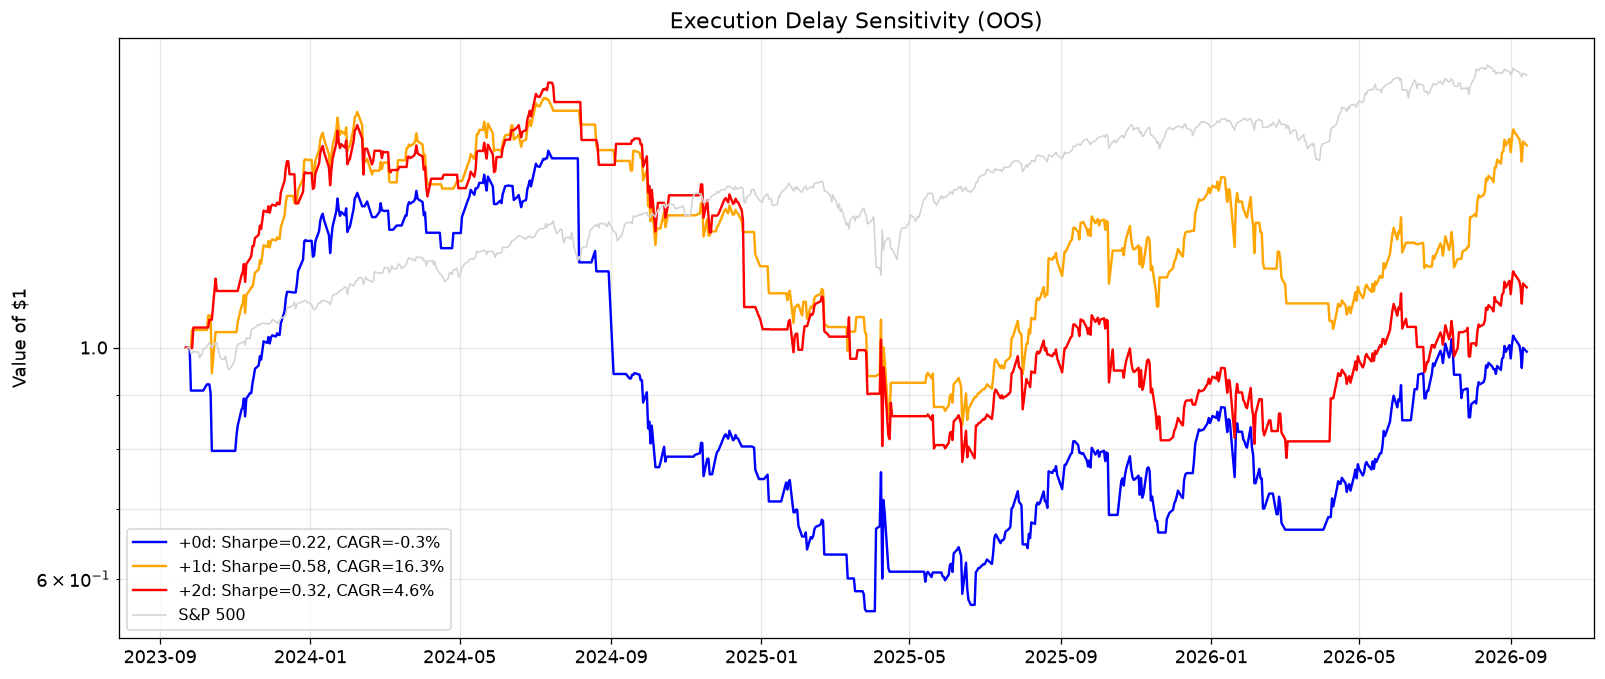

,Terminal ($1),CAGR,Vol (ann.),Sharpe,Sortino,Max DD,Trades,Days Short,Days Long,Days Cash,Period
Delay,,,,,,,,,,,
+0d,0.99,-0.3%,44.8%,0.22,0.19,-63.8%,134,472,14,261,2023-09-22 to 2026-09-14
+1d,1.56,16.3%,41.0%,0.58,0.54,-51.5%,135,472,14,261,2023-09-22 to 2026-09-14
+2d,1.14,4.6%,42.7%,0.32,0.30,-56.7%,136,471,14,262,2023-09-22 to 2026-09-14


In [32]:
def signals_delayed(data, short_thresh, long_thresh, delay=0):
    prev_roll = data['daily_roll'].shift(1 + delay)
    signal = pd.Series('CASH', index=data.index)
    signal[prev_roll >= short_thresh] = 'SVXY'
    signal[prev_roll <= long_thresh]  = 'VIXY'
    return signal

delay_results = []
fig, ax = plt.subplots(figsize=(14, 6))

for delay, color in [(0, 'blue'), (1, 'orange'), (2, 'red')]:
    sig_d = signals_delayed(data, OPT_SHORT, OPT_LONG, delay=delay)
    bt_d, stats_d = backtest(data, sig_d, start=test_start_str, end=full_end)
    if len(bt_d) > 0:
        ax.plot(bt_d.index, bt_d['etf_equity'], color=color, lw=1.5,
                label=f'+{delay}d: Sharpe={stats_d["Sharpe"]}, CAGR={stats_d["CAGR"]}')
        delay_results.append({'Delay': f'+{delay}d', **stats_d})

ax.plot(bt_d.index, bt_d['spy_equity'], color='lightgray', lw=1, label='S&P 500')
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}'))
ax.set_title('Execution Delay Sensitivity (OOS)', fontsize=14)
ax.set_ylabel('Value of $1')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

display(pd.DataFrame(delay_results).set_index('Delay'))

## 23. Robustness Check 5: Parameter Neighbourhood Stability

Test thresholds within +/-30% of optimum on OOS data.

Parameter neighbourhood (OOS): 130 combos
Sharpe: [0.08, 0.44], mean=0.23, std=0.09
% positive Sharpe: 100%


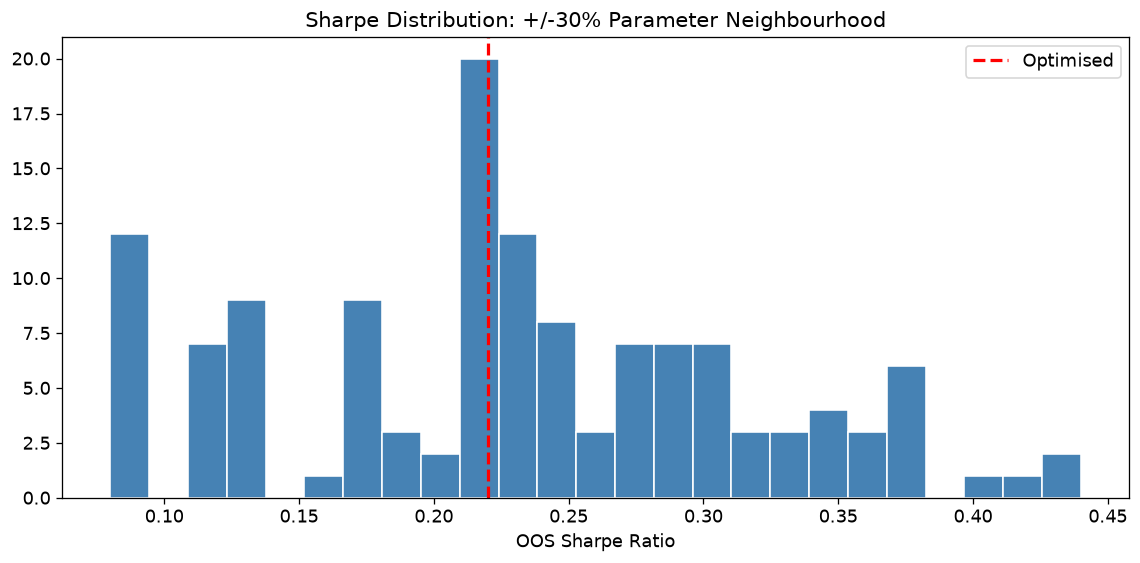

In [33]:
st_range = np.arange(OPT_SHORT * 0.7, OPT_SHORT * 1.3 + 0.001, 0.002)
lt_range = np.arange(OPT_LONG * 1.3, OPT_LONG * 0.7 + 0.001, 0.02)

neighbourhood = []
for st in st_range:
    for lt in lt_range:
        sig_n = generate_signals(data, st, lt)
        bt_n, stats_n = backtest(data, sig_n, start=test_start_str, end=full_end)
        if len(bt_n) == 0: continue
        neighbourhood.append({
            'short': round(st, 4), 'long': round(lt, 3),
            'sharpe': float(stats_n['Sharpe']),
        })

nb_df = pd.DataFrame(neighbourhood)

print(f'Parameter neighbourhood (OOS): {len(nb_df)} combos')
print(f'Sharpe: [{nb_df["sharpe"].min():.2f}, {nb_df["sharpe"].max():.2f}], '
      f'mean={nb_df["sharpe"].mean():.2f}, std={nb_df["sharpe"].std():.2f}')
print(f'% positive Sharpe: {(nb_df["sharpe"] > 0).mean():.0%}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(nb_df['sharpe'], bins=25, color='steelblue', edgecolor='white')
ax.axvline(float(stats_opt['Sharpe']), color='red', ls='--', lw=2, label='Optimised')
ax.set_xlabel('OOS Sharpe Ratio')
ax.set_title('Sharpe Distribution: +/-30% Parameter Neighbourhood')
ax.legend()
plt.tight_layout()
plt.show()

## 24. Robustness Check 6: Permutation Test (Random Signals)

1,000 random signal sequences with the same proportions.

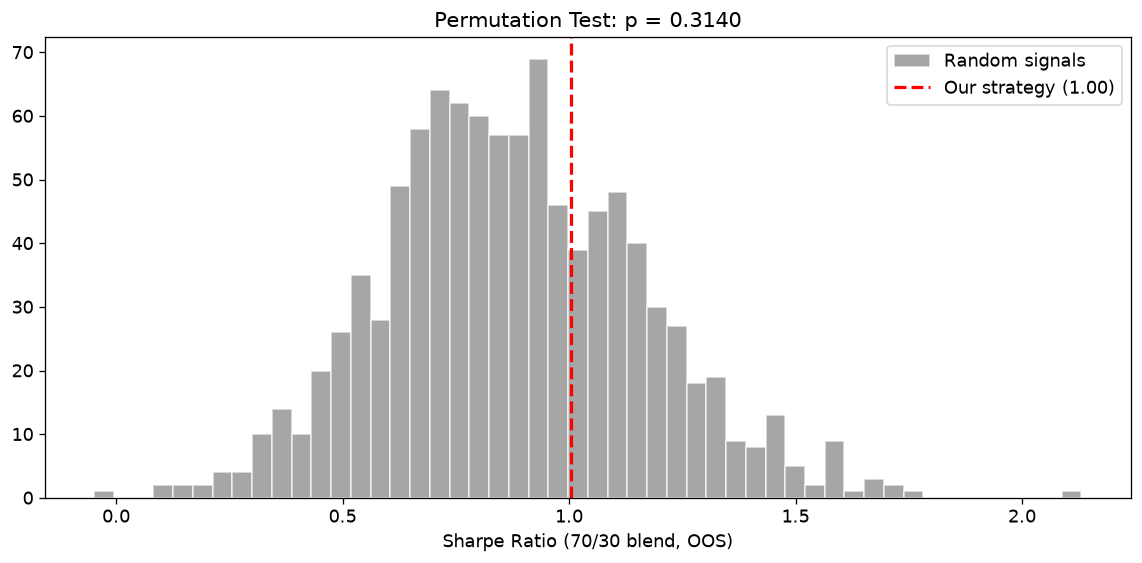

Strategy Sharpe: 1.004, Random mean: 0.877
p-value: 0.3140


In [34]:
np.random.seed(42)
N_PERMS = 1000

oos_range = data.loc[test_start_str:full_end].dropna(subset=['SVXY_ret','VIXY_ret']).copy()
oos_sig = sig_opt.reindex(oos_range.index)

n_svxy = (oos_sig == 'SVXY').sum()
n_vixy = (oos_sig == 'VIXY').sum()
n_cash = (oos_sig == 'CASH').sum()
total = len(oos_sig)
probs = [n_svxy/total, n_vixy/total, n_cash/total]

svxy_col = 'SVXY_ret_adj'

# Actual strategy Sharpe (70/30 blend with quarterly rebal — approximate with constant weight)
actual_vol_ret = np.zeros(total)
actual_vol_ret[oos_sig.values == 'SVXY'] = oos_range[svxy_col].values[oos_sig.values == 'SVXY']
actual_vol_ret[oos_sig.values == 'VIXY'] = oos_range['VIXY_ret'].values[oos_sig.values == 'VIXY']
actual_blend = 0.30 * actual_vol_ret + 0.70 * oos_range['SPY_ret'].values
actual_sharpe = (np.nanmean(actual_blend) * 252) / (np.nanstd(actual_blend) * np.sqrt(252))

random_sharpes = []
for _ in range(N_PERMS):
    rand_sig = np.random.choice(['SVXY', 'VIXY', 'CASH'], size=total, p=probs)
    rand_ret = np.zeros(total)
    rand_ret[rand_sig == 'SVXY'] = oos_range[svxy_col].values[rand_sig == 'SVXY']
    rand_ret[rand_sig == 'VIXY'] = oos_range['VIXY_ret'].values[rand_sig == 'VIXY']
    blend = 0.30 * rand_ret + 0.70 * oos_range['SPY_ret'].values
    vol = np.nanstd(blend) * np.sqrt(252)
    random_sharpes.append((np.nanmean(blend) * 252) / vol if vol > 0 else 0)

random_sharpes = np.array(random_sharpes)
pval = (random_sharpes >= actual_sharpe).mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_sharpes, bins=50, color='gray', edgecolor='white', alpha=0.7, label='Random signals')
ax.axvline(actual_sharpe, color='red', lw=2, ls='--', label=f'Our strategy ({actual_sharpe:.2f})')
ax.set_xlabel('Sharpe Ratio (70/30 blend, OOS)')
ax.set_title(f'Permutation Test: p = {pval:.4f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Strategy Sharpe: {actual_sharpe:.3f}, Random mean: {random_sharpes.mean():.3f}')
print(f'p-value: {pval:.4f}')

## 25. Robustness Scorecard

In [35]:
print('=' * 65)
print('ROBUSTNESS SCORECARD')
print('=' * 65)

cost_drag = bt_cost['equity_norm'].iloc[-1] / bt_cost['nocost_equity'].iloc[-1] - 1

checks = [
    ('Trading costs (IB EUR 20k)',
     f'Drag: {cost_drag:.1%}',
     abs(cost_drag) < 0.15),
    ('Fixed 2016 split (Volmag+COVID OOS)',
     f'Sharpe={stats_fixed["Sharpe"]}',
     float(stats_fixed['Sharpe']) > 0),
    ('Walk-forward optimisation',
     f'Sharpe={stats_wf["Sharpe"]}',
     float(stats_wf['Sharpe']) > 0),
    ('Subperiod consistency',
     f'{n_win}/{len(oos_years)} OOS years beat SPY',
     n_win > len(oos_years) * 0.4),
    ('Execution delay (+1d)',
     f'Sharpe={delay_results[1]["Sharpe"] if len(delay_results) > 1 else "N/A"}',
     len(delay_results) > 1 and float(delay_results[1].get('Sharpe', '0')) > 0),
    ('Parameter neighbourhood (+/-30%)',
     f'{(nb_df["sharpe"] > 0).mean():.0%} positive Sharpe',
     (nb_df['sharpe'] > 0).mean() > 0.70),
    ('Permutation test (p<0.05)',
     f'p = {pval:.4f}',
     pval < 0.05),
]

for name, detail, passed in checks:
    status = 'PASS' if passed else 'FAIL'
    print(f'  [{status}] {name:40s} | {detail}')

n_passed = sum(1 for _,_,p in checks if p)
print(f'\nPassed: {n_passed}/{len(checks)}')
if n_passed >= 5:
    print('Strategy appears robust enough for live trading with appropriate position sizing.')
elif n_passed >= 3:
    print('Strategy shows promise but has weaknesses. Proceed with caution.')
else:
    print('Strategy may be overfit. Reconsider before going live.')

ROBUSTNESS SCORECARD
  [PASS] Trading costs (IB EUR 20k)               | Drag: -8.2%
  [PASS] Fixed 2016 split (Volmag+COVID OOS)      | Sharpe=0.65
  [PASS] Walk-forward optimisation                | Sharpe=0.66
  [PASS] Subperiod consistency                    | 2/3 OOS years beat SPY
  [PASS] Execution delay (+1d)                    | Sharpe=0.58
  [PASS] Parameter neighbourhood (+/-30%)         | 100% positive Sharpe
  [FAIL] Permutation test (p<0.05)                | p = 0.3140

Passed: 6/7
Strategy appears robust enough for live trading with appropriate position sizing.


## Notes

1. **Pre-2007 data gap (v4 fix)**: The R downloader only fetches contracts expiring 2007+.
   In 2006, the "nearest" contract was 300+ DTE. Analysis now starts from Jan 2007.

2. **Minimum settle price (v4)**: Rows with settle < 5.0 are dropped (e.g. the erroneous
   1.0 value in 2008 data).

3. **F2 gap diagnostic (v4)**: Some near-term contracts may be missing from CBOE archives,
   causing F2 to occasionally be a 2-3 month contract. The Exhibit 3 F2 spread is computed
   only on days where F1-F2 expiry gap <= 40 calendar days.

4. **SVXY leverage change**: After Volmageddon (Feb 2018), SVXY changed from -1x to -0.5x.
   `SVXY_ret_adj` scales post-change returns by 2x (an approximation that compounds
   differently over multi-day holds — flagged as such).

5. **Quarterly rebalancing (v4)**: Portfolio blend rebalances every ~63 trading days.
   Both cost and no-cost versions use the same schedule for fair comparison.

6. **No futures strategy**: v4 focuses exclusively on the ETF implementation, which is
   what a retail investor would actually trade.
